# Track C — Mô hình hoá: dự báo review xấu và kiểm chứng "bẫy SLA" bằng sức dự đoán

**Đồ án:** *Bẻ gãy bẫy SLA trong thương mại điện tử* · Python for Data Science · HCMUTE HK1 2025–2026 · PGS.TS Nguyễn Mạnh Hùng
**Phần:** Track C — Feature & Modeling (task C1–C16, `docs/TASKS.md` §2.4) · **Người làm:** Đỗ Minh Hiển (24139013)

> **Notebook này chỉ kể chuyện.** Mọi phép tính nằm trong `src/features/` và `src/models/`, có test
> (`tests/test_features.py`, `tests/test_models.py`). Toàn bộ con số tái lập bằng **một lệnh**:
> `python3 -m src.models.run_modeling` → log `docs/evidence/c_modeling_<ngày>.txt`.

### Mục lục
1. Bài toán — dự báo cái gì, tại thời điểm nào
2. Dữ liệu vào mô hình và ba đặc thù của nó
3. Feature và kiểm toán leakage (C1, C3)
4. **Interface OOP: `BaseModel`** (C4)
5. Chia dữ liệu theo thời gian (C5)
6. **Kiểm quyết định D9 — phát hiện lớn nhất của Track C** (C2)
7. Vì sao chọn gradient boosting
8. **Tune siêu tham số — và siêu tham số được lưu ở đâu** (C8)
9. Chọn mô hình cuối
10. Hiệu chỉnh xác suất (C12)
11. Kết quả trên tập test (C6, C11)
12. **Ablation trung tâm C9: SLA vs lead time vs lời khách**
13. Nhóm feature nào thật sự mang thông tin (tầng 7)
14. Phân tích lỗi và câu hỏi về năm 2021 (C13)
15. **Tiki Trading vs bên thứ ba** (C14)
16. Kết luận, giới hạn, việc tiếp theo
17. Phụ lục — hỏi đáp lý thuyết

### Chạy notebook ở đâu

* **Máy cá nhân (output trong file này được tạo theo cách này):** mở từ thư mục repo, chọn kernel Python có
  `scikit-learn==1.5.1` (anaconda), rồi *Run All*. Trên MacBook 8 nhân hết khoảng 8 phút. Khi `USE_CACHE = True`,
  hai mô hình đã tune được đọc từ `reports/models/*.joblib` (do `python -m src.models.run_modeling` tạo). Nếu chưa có
  file đó, hoặc đặt `USE_CACHE = False`, notebook tự tune lại và mất thêm khoảng 8 phút. Phần còn lại (thang mô hình,
  C9, ablation, 1.000 lần bootstrap) đều được train/tính lại ngay trong notebook. Số liệu in ra khớp với log
  `docs/evidence/c_modeling_2026-09-27.txt`. `SMOKE = True` chạy thử trên ~15% sản phẩm để kiểm tra code (số liệu khi
  đó **không** dùng để báo cáo).
* **Kaggle (tuỳ chọn, cho máy yếu):** upload `trackc_kaggle.zip` (tạo bằng `python3 -m src.models.make_kaggle_bundle`)
  thành một Dataset **Private**, *Add data* vào notebook, bật *Internet*, rồi *Run all*. Ô dưới tự tìm mã nguồn + dữ liệu
  trong `/kaggle/input/` và ghim đúng phiên bản thư viện.

In [1]:
import os
import shutil
import sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    # ghim đúng phiên bản đã dùng để lưu mô hình (joblib phụ thuộc phiên bản scikit-learn)
    !pip install -q scikit-learn==1.5.1 pandas==2.2.2
    bundle = next(p.parents[2] for p in Path("/kaggle/input").rglob("src/models/base.py"))
    ROOT = Path("/kaggle/working/project")
    if not ROOT.exists():
        shutil.copytree(bundle, ROOT)          # /kaggle/input chỉ đọc; cần chỗ ghi evidence & mô hình
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Thư mục dự án:", ROOT, "| Kaggle:", ON_KAGGLE)

Thư mục dự án: /Users/dominhhien/Documents/HCMUTE_HK1_2025/KHDL/datascience_hcmute | Kaggle: False


In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone

from src.evaluate.stats import effective_sample_size
from src.features.build import (CATEGORICAL, EX_ANTE_FEATURES, EX_POST_FEATURES, FEATURE_GROUPS,
                                PRIOR_STRENGTH, TARGET, WEIGHT, YEAR, temporal_split)
from src.features.history import asof_group_stats, asof_group_stats_loop
from src.features.leakage import EX_POST, FORBIDDEN, LeakageError, audit_features
from src.models import plots
from src.models.base import BaseModel
from src.models.diagnostics import (dose_response_by_era, five_star_recency, group_ablation,
                                    paired_comparisons, partial_dependence,
                                    permutation_importance_table, segment_report,
                                    sla_trap_difference, sla_trap_table, univariate_auc_table)
from src.models.experiments import (ARTIFACT_DIR, CLEAN_PATH, CV, FINAL_MODEL, GBM_SEARCH_SPACE,
                                    LOGISTIC_SEARCH_SPACE, build_ladder, choose_scheme,
                                    compare_families_and_weights, evaluation_table, final_candidates,
                                    fit_c9, fit_ladder, kfold_vs_temporal, load_frame, load_or_tune,
                                    tune_gbm, tune_logistic)
from src.models.run_modeling import C9_PAIRS, C9_SCHEME, EXPOST_PAIR, REPORT_METRICS, TEST_PAIRS

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
plots.apply_theme()

USE_CACHE = True   # True: đọc mô hình đã tune ở reports/models/ (run_modeling tạo). False: tune lại (~8 phút)
SMOKE = False      # True: chạy thử nhanh trên ~15% sản phẩm để kiểm tra code — KHÔNG dùng số liệu để báo cáo
N_BOOT = 30 if SMOKE else 1000   # số lần bootstrap theo cụm cho mọi khoảng tin cậy

## 1. Bài toán — dự báo cái gì, tại thời điểm nào

**Câu hỏi của cả đồ án:** *tỉ lệ đạt SLA có phản ánh trải nghiệm khách hàng không?* `FINDINGS.md` §4 đã trả lời bằng
**so sánh trung bình**: nhãn khách tự báo phân biệt mức rating tốt hơn chỉ báo SLA. Track C trả lời lại câu đó bằng một
**phương pháp độc lập — sức dự đoán**. Nếu chỉ báo SLA mang ít thông tin về sự bất mãn thì một mô hình chỉ dùng nó
sẽ gần như không đoán được review xấu, dù được huấn luyện tốt đến đâu.

| Thành phần | Lựa chọn | Lý do |
|---|---|---|
| Biến mục tiêu | `is_low_rating = rating ≤ 3` (quyết định D2) | có trên ~198 nghìn dòng; `customer_says_late` chỉ ~316 ca dương — quá mỏng để làm mục tiêu |
| **Thời điểm dự báo** | **lúc đơn được giao**, trước khi khách viết review | ứng dụng thật: CSKH chủ động liên hệ đơn rủi ro *trước* khi review xấu xuất hiện |
| Đầu ra | xác suất `P(review xấu)`, không phải nhãn 0/1 | để xếp hạng đơn rủi ro, và để kiểm tra xác suất có đáng tin không |
| Tầng `ex-ante` | chỉ feature đã biết lúc giao | mô hình **dự báo** (M0–M7) |
| Tầng `ex-post` | thêm tín hiệu khách khai cùng lúc với số sao | mô hình **giải thích** — dùng cho C9 và M8 |

Ba đặc điểm quyết định gần như mọi lựa chọn phương pháp bên dưới:
1. **mất cân bằng nặng** — quần thể chỉ ~2–4% review ≤3★;
2. **dữ liệu lấy mẫu phân tầng theo số sao** — mẫu không giống quần thể;
3. **có trục thời gian** — mô hình phải dự báo tương lai, không phải nội suy quá khứ.

## 2. Dữ liệu vào mô hình và ba đặc thù của nó

`build_features()` nhận bảng đã làm sạch (`data/processed/reviews_clean.parquet`, do Track A/`run_clean` tạo) và chỉ giữ các
dòng `is_analysable` (có `lead_days` hợp lệ). Chia theo **năm đăng review** (D3): train ≤2023 · test 2024–2026.

In [3]:
clean = pd.read_parquet(CLEAN_PATH)
frame = load_frame()
if SMOKE:  # lấy mẫu theo SẢN PHẨM (giữ nguyên cấu trúc cụm), không lấy mẫu theo dòng
    keep = pd.Series(frame["product_id"].unique()).sample(frac=0.15, random_state=0)
    frame = frame[frame["product_id"].isin(keep)].reset_index(drop=True)
    print(f"⚠️ SMOKE: chỉ {len(frame):,} dòng — số liệu dưới đây KHÔNG dùng để báo cáo")
train, test = temporal_split(frame)

pd.DataFrame({
    name: {
        "số dòng": len(d),
        "số ca dương": int(d[TARGET].sum()),
        "tỉ lệ dương — mẫu thô": d[TARGET].mean(),
        "tỉ lệ dương — quần thể (có trọng số)": np.average(d[TARGET], weights=d[WEIGHT]),
        "n_eff (Kish)": effective_sample_size(d[WEIGHT].to_numpy()),
        "dòng thuộc sản phẩm vét cạn": int(d["is_census"].sum()),
    }
    for name, d in (("train ≤2023", train), ("test 2024–2026", test))
}).T

,số dòng,số ca dương,tỉ lệ dương — mẫu thô,tỉ lệ dương — quần thể (có trọng số),n_eff (Kish),dòng thuộc sản phẩm vét cạn
train ≤2023,"157,173.0000","15,132.0000",0.0963,0.0445,"41,274.2255","61,649.0000"
test 2024–2026,"41,182.0000","1,465.0000",0.0356,0.0168,"13,099.6956","24,626.0000"


**Đặc thù 1 — mẫu phân tầng.** Scraper vét cạn review 1–3★ nhưng chỉ lấy tối đa 200 review 5★ mỗi sản phẩm, nên mẫu
có tỉ lệ review xấu cao gấp đôi quần thể. Trọng số `w = N_h / n_h` (số review thật / số review đã lấy của tầng sao đó)
đưa mọi ước lượng về quần thể. **Mọi metric trong notebook này đều có trọng số.**

**Đặc thù 2 — trôi dạt theo thời gian.** Tỉ lệ review xấu (có trọng số) giảm mạnh qua các năm. Mô hình học trên quá
khứ sẽ luôn "đoán cao" cho tương lai nếu không hiệu chỉnh (§10).

In [4]:
by_year = frame.groupby(YEAR).apply(lambda d: pd.Series({
    "n": len(d), "ca dương": int(d[TARGET].sum()),
    "tỉ lệ quần thể": np.average(d[TARGET], weights=d[WEIGHT]),
    "vượt SLA (quần thể)": np.average(d["sla_breach"], weights=d[WEIGHT]),
    "tập": "train" if d.name <= 2023 else "test"}), include_groups=False)
by_year[by_year["n"] >= 400]

,n,ca dương,tỉ lệ quần thể,vượt SLA (quần thể),tập
year,,,,,
2017,439,96,0.1675,0.1717,train
2018,887,224,0.1502,0.1259,train
2019,3269,852,0.1179,0.0911,train
2020,18458,3485,0.1061,0.0598,train
2021,52584,5637,0.0519,0.1675,train
2022,54829,3614,0.0283,0.0462,train
2023,26591,1204,0.0195,0.0207,train
2024,18369,665,0.0166,0.0142,test
2025,14458,509,0.0168,0.0327,test


**Đặc thù 3 — phát hiện mới: tầng 5★ bị lệch về review gần đây.** API trả review trong một tầng sao theo thứ tự ưu tiên
review mới, không ngẫu nhiên. Ở sản phẩm bị giới hạn tầng 5★, review 5★ lấy được mới hơn hẳn review 1–3★ (vét cạn):

In [5]:
five_star_recency(clean)

,giá trị
số sản phẩm bị giới hạn tầng 5★,371.0000
số sản phẩm đủ dữ liệu để so,344.0000
trung vị (ngày 5★ − ngày 1–3★),272.5000
tỉ lệ sản phẩm có 5★ mới hơn,0.9593


Hệ quả: `w = N_h / n_h` là trọng số **đúng cho ước lượng toàn thời gian** (đã kiểm chứng: `Σw` khớp số review thật tới
0,009%), nhưng khi **cắt theo năm** thì review 5★ bị dồn về các năm gần, còn các năm cũ bị thiếu 5★. Không có dữ liệu để
sửa triệt để (API không cho biết ngày của review 5★ không được cào).

**Cách xử lý: một tập đánh giá thứ hai không có lấy mẫu nào.** Ở 2.066 sản phẩm, scraper đã vét cạn *mọi* tầng sao
(`stratum_sampled = stratum_size`) — với các sản phẩm này, **mẫu chính là quần thể**, trọng số đều bằng 1, không có
thiên lệch thời gian. Mọi kết luận của Track C được chấm trên **cả hai** tập: *toàn bộ test (có trọng số)* và
*sản phẩm vét cạn (không lấy mẫu)*. Kết luận nào chỉ đúng trên một tập thì không được coi là kết luận.

> 📌 Phát hiện này ảnh hưởng tới **mọi ước lượng theo năm của cả nhóm** (vd bảng vượt SLA theo năm ở `FINDINGS.md` §2),
> không riêng Track C — cần báo Track A.

## 3. Feature và kiểm toán leakage (C1, C3)

### 3.1 Danh sách biến cấm — tầng 3 của khung chứng minh

**Leakage** = mô hình dùng thông tin mà lúc dự báo thật sẽ không có. Hậu quả: điểm đánh giá đẹp, triển khai thì sập.
Nguyên tắc duy nhất: *một biến chỉ được làm feature nếu giá trị của nó đã biết tại thời điểm dự báo (lúc giao hàng)*.
Các biến bị cấm rơi vào bốn nhóm: **chính là nhãn đổi tên** (`stratum`, `weight`, `title`), **hệ quả của nhãn**
(`thank_count` — review 1★ được bấm "cảm ơn" nhiều hơn *sau khi* đăng: nhân quả ngược), **thông tin tương lai**
(ảnh chụp sản phẩm lúc cào như `rating_average` chứa luôn review cần dự báo), và **trùng thông tin tuyệt đối**
(`gap_days = lead_days − 5`). Danh sách nằm trong code và được kiểm **tự động** mỗi khi khai báo mô hình:

In [6]:
pd.DataFrame({"lý do bị cấm": FORBIDDEN}).rename_axis("biến")

,lý do bị cấm
biến,
rating,chính là biến gốc của nhãn is_low_rating
is_low_rating,biến mục tiêu
stratum,tầng lấy mẫu = số sao của review → chính là nhãn
stratum_size,số review cùng số sao của sản phẩm → hàm của nhãn
stratum_sampled,số review đã cào ở tầng sao đó → hàm của nhãn
weight,w = N_h/n_h phụ thuộc tầng sao → hàm của nhãn;...
title,tiêu đề Tiki tự sinh theo số sao (vd 'Cực kì h...
content,văn bản viết cùng lúc với số sao — dùng nó là ...
thank_count,lượt 'cảm ơn' người khác bấm SAU khi review đă...


In [7]:
print("Biến hậu nghiệm (chỉ hợp lệ ở tầng ex-post):", sorted(EX_POST))
for feats, tier, linear in ((["lead_days", "weight"], "ex_ante", False),
                            (["lead_days", "customer_says_late"], "ex_ante", False),
                            (["lead_days", "sla_breach"], "ex_ante", True)):
    try:
        audit_features(feats, tier=tier, linear=linear)
    except LeakageError as err:
        print(f"\n{feats} (tier={tier}, linear={linear}) → CHẶN\n{err}")

Biến hậu nghiệm (chỉ hợp lệ ở tầng ex-post): ['customer_says_late', 'dr_dong_goi_bad', 'dr_gio_giao_bad', 'dr_shipper_bad', 'has_delivery_rating', 'n_images', 'review_lag_days']

['lead_days', 'weight'] (tier=ex_ante, linear=False) → CHẶN
Vi phạm quy tắc chống leakage:
  - weight: w = N_h/n_h phụ thuộc tầng sao → hàm của nhãn; chỉ dùng để ĐÁNH GIÁ

['lead_days', 'customer_says_late'] (tier=ex_ante, linear=False) → CHẶN
Vi phạm quy tắc chống leakage:
  - customer_says_late: biến hậu nghiệm, chỉ hợp lệ ở tầng ex_post

['lead_days', 'sla_breach'] (tier=ex_ante, linear=True) → CHẶN
Vi phạm quy tắc chống leakage:
  - lead_days + sla_breach: trùng thông tin, không đứng chung mô hình tuyến tính


### 3.2 Feature đã dùng — 17 biến ex-ante chia 6 nhóm

| Nhóm | Feature | Ý nghĩa |
|---|---|---|
| `giao_hang` | `lead_days`, `delivered_hour`, `delivered_weekend` | thời gian giao thực tế, giờ và ngày nhận |
| `thoi_diem_mua` | `purchase_month`, `purchase_weekday`, `purchase_hour` | mùa vụ (Tết, sale 11.11…), thói quen mua |
| `san_pham` | `category`, `is_tiki_trading`, `log_price`, `discount_rate` | ngành hàng, hàng sàn tự bán hay bên thứ ba, giá |
| `lich_su_san_pham` | `prod_hist_n`, `prod_hist_rate` | *tính tới lúc giao*: sản phẩm đã có bao nhiêu review, tỉ lệ review xấu |
| `lich_su_nha_ban` | `seller_hist_n`, `seller_hist_rate` | như trên, cho nhà bán |
| `khach_hang` | `cust_tenure_days`, `cust_hist_n`, `cust_hist_rate` | thâm niên tài khoản; khách này trước đây có hay chấm thấp không |

Tầng ex-post thêm 7 biến: `customer_says_late`, `dr_shipper_bad`, `dr_gio_giao_bad`, `dr_dong_goi_bad`,
`has_delivery_rating`, `n_images`, `review_lag_days`.

`log_price`, `discount_rate` là **ảnh chụp lúc cào** — giả định là thuộc tính tĩnh của sản phẩm (giới hạn đã khai báo).
`customer_purchased_flag` bị loại vì 99,9% là `True` (không mang thông tin).

### 3.3 Feature lịch sử "tính tới thời điểm dự báo" (as-of)

Với mỗi đơn `i` giao lúc $t_i$, feature lịch sử của sản phẩm chỉ cộng các review $j$ **cùng sản phẩm**, đăng **trước**
$t_i$, và không bao giờ gồm chính $i$:

$$\text{prod\_hist\_rate}_i = \frac{\sum_{j:\ t^{\text{review}}_j < t_i,\ j\neq i} w_j\, y_j \;+\; m\,p_0}{\sum_{j:\ t^{\text{review}}_j < t_i,\ j\neq i} w_j \;+\; m}$$

* **Có trọng số** $w_j$: tổng có trọng số là ước lượng Horvitz–Thompson của tổng quần thể — đếm thô sẽ phóng đại tỉ lệ
  sao thấp vì tầng 1–3★ bị vét cạn.
* **Làm trơn Bayes thực nghiệm** ($m$ = `PRIOR_STRENGTH`, $p_0$ = tỉ lệ chung **chỉ ước lượng trên train**): tương
  đương đặt prior $\text{Beta}(m p_0,\ m(1-p_0))$ cho tỉ lệ của mỗi sản phẩm. Sản phẩm mới có một review xấu không bị
  gán 100% mà bị kéo về $p_0$; càng nhiều review thì dữ liệu riêng càng thắng prior.
* **Cài đặt vector hoá** bằng một lần sắp xếp + `np.searchsorted` cho mọi nhóm cùng lúc (Buổi 2). Test
  `test_ban_vector_hoa_khop_ban_vong_lap` kiểm chứng nó cho **đúng từng số** như bản vòng lặp thuần. So tốc độ:

In [8]:
demo = clean[clean["review_ts"].notna() & clean["delivered_ts"].notna()].head(3000)
args = (demo["product_id"], demo["review_ts"], demo["delivered_ts"], demo["is_low_rating"].astype(float),
        demo["weight"], 0.05, PRIOR_STRENGTH)
print(f"{len(demo):,} dòng · {demo['product_id'].nunique()} sản phẩm")
print("Vòng lặp Python thuần:")
%timeit -n 1 -r 3 asof_group_stats_loop(*args)
print("Vector hoá (sort + np.searchsorted):")
%timeit -n 5 -r 3 asof_group_stats(*args)
np.testing.assert_allclose(asof_group_stats(*args)[1], asof_group_stats_loop(*args)[1])
print("→ hai bản cho kết quả giống hệt nhau")

3,000 dòng · 56 sản phẩm
Vòng lặp Python thuần:


754 ms ± 12.3 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)
Vector hoá (sort + np.searchsorted):
3.07 ms ± 570 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


→ hai bản cho kết quả giống hệt nhau


In [9]:
frame[EX_ANTE_FEATURES].describe().T[["count", "mean", "std", "min", "50%", "max"]]

,count,mean,std,min,50%,max
lead_days,"198,355.0000",2.3838,4.3854,0.0004,1.4503,89.9933
delivered_hour,"198,355.0000",12.4518,3.0469,0.0000,12.0000,23.0000
delivered_weekend,"198,355.0000",0.2268,0.4188,0.0000,0.0000,1.0000
purchase_month,"198,355.0000",6.6269,3.4972,1.0000,7.0000,12.0000
purchase_weekday,"198,355.0000",2.8917,1.9863,0.0000,3.0000,6.0000
purchase_hour,"198,355.0000",13.6700,5.7831,0.0000,14.0000,23.0000
category,"198,355.0000",5.3701,2.8285,0.0000,7.0000,9.0000
is_tiki_trading,"198,355.0000",0.6748,0.4684,0.0000,1.0000,1.0000
log_price,"198,355.0000",11.9792,0.8739,8.5174,11.9117,17.3285
discount_rate,"198,355.0000",20.0475,14.8138,0.0000,21.0000,84.0000


## 4. Interface OOP: `BaseModel` (C4)

### 4.1 Vì sao cần một interface

Thang mô hình (baseline → logistic → cây → tuned → hiệu chỉnh → ensemble) chỉ so sánh được **công bằng** khi mọi mô hình
đi qua *cùng một* vòng đánh giá: cùng tập dòng, cùng cách chọn cột, cùng metric có trọng số. `BaseModel` là **hợp đồng**
bảo đảm điều đó: vòng đánh giá chỉ gọi `fit` / `predict_proba` và không cần biết mình đang chấm lớp nào.

```
      sklearn.base.ClassifierMixin     sklearn.base.BaseEstimator        abc.ABC
                     \                           |                        /
                      └───────────────────── BaseModel ──────────────────┘
          fit() · predict_proba() · predict() · score() · tune() · with_features()
          save() · load() · export_hyperparams()                 ← viết MỘT lần ở lớp cha
          _fit() · _predict_positive()                           ← @abstractmethod: lớp con BẮT BUỘC cài
    ┌─────────────┬──────────────┬──────────────┬───────────────────┬──────────────────┬───────────────┐
 PriorBaseline  LogisticModel   GBMModel   RandomForestModel   CalibratedModel     EnsembleModel
    (M0)       (M1a,M1b,M2)   (M4,M5,M8)        (M3)            «Decorator»        «Composite»
                                                            chứa 1 BaseModel   chứa n BaseModel
```

| Khái niệm OOP | Cài ở đâu | Lợi ích cụ thể trong đồ án |
|---|---|---|
| **Lớp trừu tượng** (`ABC`, `@abstractmethod`) | `BaseModel._fit`, `_predict_positive` | lớp con quên cài → lỗi ngay khi khởi tạo, không đợi tới lúc chạy |
| **Template method** | `fit()` kiểm tra đầu vào, chọn cột, ghi `classes_` rồi gọi `_fit()` | không lớp con nào quên kiểm tra đầu vào hay kẹp xác suất vào [0, 1] |
| **Kế thừa** | `tune()`, `save()`, `export_hyperparams()` | viết một lần, mọi mô hình (kể cả ensemble) đều tune/lưu được |
| **Đa hình** (polymorphism) | vòng đánh giá, `with_features()` | thêm mô hình mới không sửa dòng nào của code đánh giá (nguyên lý đóng–mở) |
| **Ghi đè** (override) | `score()` = PR-AUC thay cho accuracy; `with_features()` ở lớp bọc | hành vi đúng cho dữ liệu lệch, lớp bọc tự truyền xuống lớp con |
| **Decorator** | `CalibratedModel` *là* và *chứa* một `BaseModel` | hiệu chỉnh bất kỳ mô hình nào mà không sửa mô hình đó |
| **Composite** | `EnsembleModel` *là* và *chứa* nhiều `BaseModel` | ensemble dùng được ở mọi chỗ một mô hình đơn dùng được |
| **Đóng gói theo quy ước scikit-learn** | siêu tham số = tham số `__init__`; thuộc tính học được có đuôi `_` | `clone`, `get_params`, `set_params` hoạt động; phân biệt rõ "cấu hình" và "đã học" |

### 4.2 Template method trong code

In [10]:
import inspect
print(inspect.getsource(BaseModel.fit))
try:
    BaseModel()
except TypeError as err:
    print("BaseModel() →", err)

    def fit(self, X: pd.DataFrame, y, sample_weight=None) -> "BaseModel":
        """Kiểm tra đầu vào → chọn cột → gọi `_fit` của lớp con. Trả về chính nó."""
        Xs = self._select(X)
        y_arr = np.asarray(y).astype(int).ravel()
        if len(y_arr) != len(Xs):
            raise ValueError(f"X có {len(Xs)} dòng nhưng y có {len(y_arr)}")
        if not np.isin(y_arr, (0, 1)).all():
            raise ValueError("y phải là nhãn nhị phân 0/1")
        sw = None if sample_weight is None else np.asarray(sample_weight, dtype=float).ravel()
        if sw is not None and (len(sw) != len(y_arr) or np.any(sw < 0)):
            raise ValueError("sample_weight phải cùng độ dài với y và không âm")

        self.classes_ = np.array([0, 1])
        self.feature_names_in_ = np.asarray(Xs.columns, dtype=object)
        self.n_features_in_ = Xs.shape[1]
        self._fit(Xs, y_arr, sw)
        return self

BaseModel() → Can't instantiate abstract class BaseModel without an implementation for ab

### 4.3 Hai loại thuộc tính — nền tảng để trả lời "siêu tham số lưu ở đâu"

Quy ước scikit-learn mà `BaseModel` tuân theo:

* **Siêu tham số** (hyperparameter — do *người* chọn, trước khi train): là **tham số của `__init__`**, được gán **nguyên
  văn** thành thuộc tính cùng tên, không xử lý gì thêm: `self.learning_rate = learning_rate`. Nhờ vậy `get_params()`
  đọc được chúng bằng introspection chữ ký hàm, `set_params()` ghi đè được, và `clone()` tạo được bản sao *chưa train*
  với đúng bộ siêu tham số đó.
* **Tham số / trạng thái học được** (do *dữ liệu* quyết định, trong lúc `fit`): có **dấu gạch dưới ở cuối** —
  `estimator_` (các cây đã học), `classes_`, `n_iter_` (số cây sau dừng sớm), `best_params_`… Chúng **chỉ tồn tại sau
  `fit`/`tune`**; `check_is_fitted()` dựa đúng vào quy ước này để biết mô hình đã train chưa.

Mọi mô hình trong đồ án đi qua đúng một vòng lặp — đó là đa hình:

In [11]:
from src.models.baseline import PriorBaseline
from src.models.linear import LogisticModel
from src.models.trees import GBMModel, RandomForestModel

sample = train.sample(20_000, random_state=0)
for model in (PriorBaseline(), LogisticModel(features=["lead_days"], spline_features=("lead_days",)),
              GBMModel(features=EX_ANTE_FEATURES, categorical=CATEGORICAL, max_iter=50),
              RandomForestModel(features=EX_ANTE_FEATURES, n_estimators=50)):
    model.fit(sample, sample[TARGET], sample_weight=sample[WEIGHT])          # cùng một lời gọi
    p = model.predict_proba(test)[:, 1]                                       # cùng một lời gọi
    learned = sorted(k for k in vars(model) if k.endswith("_"))
    print(f"{type(model).__name__:18s} PR-AUC={model.score(test, test[TARGET], test[WEIGHT]):.4f} "
          f"· siêu tham số: {len(model.get_params(deep=False))} · đã học: {learned}")

PriorBaseline      PR-AUC=0.0168 · siêu tham số: 1 · đã học: ['classes_', 'feature_names_in_', 'n_features_in_', 'prior_']


LogisticModel      PR-AUC=0.0245 · siêu tham số: 7 · đã học: ['classes_', 'feature_names_in_', 'n_features_in_', 'pipeline_']


GBMModel           PR-AUC=0.0413 · siêu tham số: 15 · đã học: ['classes_', 'estimator_', 'feature_names_in_', 'n_features_in_']


RandomForestModel  PR-AUC=0.0506 · siêu tham số: 8 · đã học: ['classes_', 'feature_names_in_', 'n_features_in_', 'pipeline_']


## 5. Chia dữ liệu theo thời gian (C5)

**Vì sao không dùng KFold ngẫu nhiên.** KFold xáo trộn cho mô hình học từ review 2023 để đoán review 2021: nó được
"nhìn trước" xu hướng giao hàng, sản phẩm mới, lịch sử đã tích luỹ. Điểm CV khi đó đo khả năng *nội suy* quá khứ, không
phải khả năng *dự báo* tương lai — và **chọn sai siêu tham số** vì tối ưu cho một bài toán khác bài toán thật.

**Cách làm: expanding window / rolling-origin.** Mọi lựa chọn (trọng số, họ mô hình, siêu tham số) quyết định bằng CV
chỉ trong tập train ≤2023; mỗi fold train trên các năm *trước* năm kiểm định. Tập test 2024–2026 chỉ chấm **một lần**
ở cuối cho các mô hình đã chốt.

In [12]:
CV.describe(train, train[TARGET])

,train,val,n_train,n_val,dương_train,dương_val
fold,,,,,,
1,2014–2021,2022,75753,54829,10314,3614
2,2014–2022,2023,130582,26591,13928,1204


**Đo được độ lạc quan giả của KFold** — cùng một mô hình logistic, cùng dữ liệu, chỉ khác cách chia:

In [13]:
kfold_table = kfold_vs_temporal(train, scheme="survey_balanced")
kfold_table

,PR-AUC CV
cách chia,
KFold xáo trộn 5 fold (SAI),0.1296
"theo năm: val 2022, 2023 (ĐÚNG)",0.0553


Cột trên cao hơn cột dưới là phần "điểm ảo" mà cách chia sai sẽ báo cáo. Tiền xử lý (điền thiếu, chuẩn hoá) nằm **bên
trong** pipeline của mô hình nên được `fit` lại trong từng fold — không một thống kê nào của phần kiểm định lọt vào.

## 6. Kiểm quyết định D9 — phát hiện lớn nhất của Track C (C2)

**D9 (nhóm chốt 2026-09-22): train KHÔNG trọng số, đánh giá CÓ trọng số.** Lập luận gốc đến từ dịch tễ học: lấy mẫu
*case-control* (chọn nhiều ca bệnh hơn tỉ lệ thật) vẫn cho hồi quy logistic **nhất quán về độ dốc**, chỉ lệch hệ số chặn
(Prentice & Pyke, 1979). Nếu vậy thì train không trọng số vô hại, lại còn cho mô hình thấy nhiều ca hiếm hơn.

**Nhưng định lý có một điều kiện:** xác suất một quan sát được đưa vào mẫu chỉ được phụ thuộc vào **nhãn**, không phụ
thuộc vào **feature**. Ở đây, xác suất một review 5★ được cào là $n_h/N_h$ — **phụ thuộc sản phẩm**: sản phẩm càng đông
review thì tầng 5★ càng bị cắt mạnh. Tức là xác suất vào mẫu phụ thuộc feature (độ phổ biến, nhà bán, ngành) → điều
kiện bị vi phạm → quan hệ feature–nhãn trên mẫu thô có thể **sai cả chiều**.

**Kiểm bằng dữ liệu (chỉ tập train).** Mỗi feature đứng một mình, AUC trên mẫu thô so với AUC có trọng số (quần thể):

,auc_mau_tho,auc_quan_the,đảo_chiều
seller_hist_n,0.4527,0.3420,False
prod_hist_n,0.5540,0.3762,True
cust_hist_n,0.4508,0.4484,False
is_tiki_trading,0.5266,0.4499,True
cust_tenure_days,0.4518,0.4648,False
discount_rate,0.5594,0.4730,True
delivered_weekend,0.4940,0.4933,False
purchase_weekday,0.5030,0.5052,False
purchase_hour,0.5104,0.5077,False
purchase_month,0.5180,0.5216,False


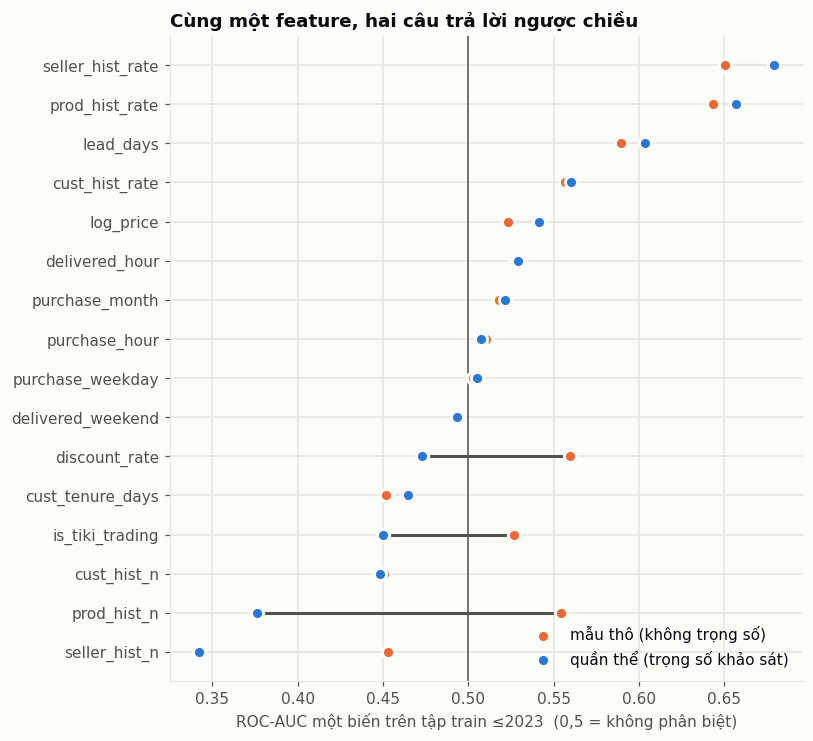

In [14]:
flip = univariate_auc_table(train, [f for f in EX_ANTE_FEATURES if f != "category"])
display(flip.sort_values("auc_quan_the"))
plots.plot_sign_flip(flip);

Những feature có hai chấm nằm **hai phía** vạch 0,5 (đường nối đậm) bị đảo chiều. Ví dụ `prod_hist_n` (độ phổ biến sản
phẩm): trên mẫu thô, sản phẩm đông review *trông như* có nhiều review xấu hơn — vì tầng 5★ của chúng bị cắt mạnh nhất;
trên quần thể thì ngược lại, sản phẩm đông review có **ít** review xấu hơn hẳn. Một mô hình train không trọng số sẽ học
đúng cái chiều sai đó.

**Hệ quả lên mô hình** — 3 họ mô hình × 3 phương án trọng số khi train, chấm bằng CV theo thời gian (PR-AUC có trọng số):

* `none` — D9 gốc;
* `survey` — trọng số khảo sát: hàm mất mát trên mẫu trở thành ước lượng **không chệch** của hàm mất mát trên quần thể
  (importance weighting): $\mathbb{E}_{\text{quần thể}}[\ell] \propto \mathbb{E}_{\text{mẫu}}[w\,\ell]$;
* `survey_balanced` — như `survey` rồi nhân lớp dương lên cho tổng trọng số hai lớp bằng nhau: vừa sửa chệch lấy mẫu,
  vừa buộc mô hình chú ý lớp hiếm (cái giá: xác suất bị phồng → phải hiệu chỉnh, §10).

trọng số train,none,survey,survey_balanced
họ mô hình,,,
Gradient boosting,0.0293,0.0502,0.0552
Logistic (L2),0.0352,0.0548,0.0553
Random forest,0.0284,0.0511,0.0479


→ phương án trọng số được chọn bằng CV: survey_balanced


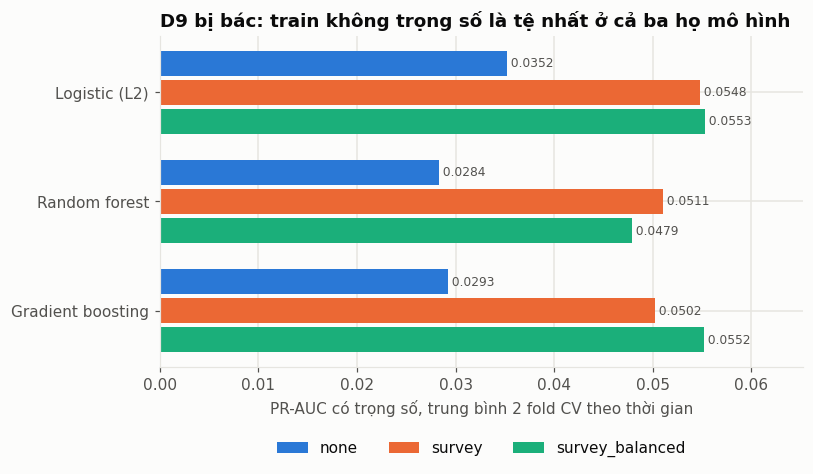

In [15]:
families = compare_families_and_weights(train)
scheme = choose_scheme(families)
display(families.pivot(index="họ mô hình", columns="trọng số train", values="mean"))
plots.plot_grouped_bars(families, "họ mô hình", "trọng số train", "mean",
                        "D9 bị bác: train không trọng số là tệ nhất ở cả ba họ mô hình",
                        "PR-AUC có trọng số, trung bình 2 fold CV theo thời gian");
print("→ phương án trọng số được chọn bằng CV:", scheme)

**Kết luận §6.** Train không trọng số (`none`) thua ở **cả ba** họ mô hình, trên **cả hai** fold — không phải nhiễu.
Quyết định D9 phần "train" được thay bằng **train có trọng số khảo sát + cân bằng lớp**; phần "đánh giá có trọng số"
giữ nguyên. Lựa chọn này ra từ CV trên tập train, không nhìn tập test.

> **Ghi chú minh bạch về quy trình.** Hiện tượng này được phát hiện lần đầu khi gỡ lỗi: mô hình đủ feature train không
> trọng số cho PR-AUC trên test *thấp hơn* mô hình chỉ dùng `lead_days`. Quyết định chính thức ở trên dựa hoàn toàn vào
> bằng chứng trên tập train (bảng AUC đảo chiều + CV), nhưng người đọc nên biết thứ tự phát hiện. Cần báo cả nhóm vì D9
> là quyết định chung.

## 7. Vì sao chọn gradient boosting

**Ba họ mô hình ứng viên, chọn vì chúng đại diện cho ba cách học khác nhau:**

| | Logistic (L2) | Random forest | Gradient boosting (histogram) |
|---|---|---|---|
| Dạng hàm | $\text{logit}\,p = \beta_0 + \beta^\top x$ — tuyến tính | trung bình $B$ cây sâu độc lập | tổng $M$ cây nhỏ học **tuần tự** |
| Giảm lỗi nào | độ chệch cao, phương sai thấp | **giảm phương sai** (bagging) | **giảm độ chệch** từng bước |
| Tương tác / phi tuyến | không (trừ khi tự tạo) | có | có |
| Giá trị thiếu | phải điền | phải điền | **tự học nhánh cho NaN** |
| Diễn giải | $e^{\beta}$ = tỉ số odds | khó | khó (dùng permutation importance, PDP) |
| Ngoại suy ngoài miền train | tuyến tính, mượt | hằng số | hằng số |

**Gradient boosting hoạt động thế nào (Friedman, 2001).** Mô hình là tổng các cây: $F_M(x) = F_0 + \eta \sum_{m=1}^{M} f_m(x)$.
Ở bước $m$, cây mới $f_m$ khớp **gradient âm của hàm mất mát** theo dự báo hiện tại — với log-loss, gradient âm đúng
bằng phần dư $r_i = y_i - p_i$. Tức là mỗi cây học "những gì mô hình hiện tại còn đoán sai" — **gradient descent trong
không gian hàm**. Giá trị mỗi lá lấy theo bước Newton có phạt L2:

$$w^*_{\text{lá}} = -\frac{\sum_{i\in \text{lá}} g_i}{\sum_{i\in \text{lá}} h_i + \lambda}, \qquad g_i = p_i - y_i,\quad h_i = p_i(1-p_i)$$

với $\lambda$ = `l2_regularization`. $\eta$ = `learning_rate` co mỗi bước lại để các cây sau có việc làm — $\eta$ nhỏ cần
nhiều cây hơn nhưng khái quát hoá tốt hơn (shrinkage).

**Bản histogram (`HistGradientBoostingClassifier`, thuật toán của LightGBM — Ke et al., 2017):** chia mỗi feature thành
≤255 bin trước, nên tìm điểm cắt tốn $O(\text{bin})$ thay vì $O(n)$ → train ~200 nghìn dòng trong vài giây; mọc cây
**theo lá** (luôn tách lá giảm loss nhiều nhất, giới hạn bằng `max_leaf_nodes`); xử lý **NaN tự nhiên** (quan trọng:
`cust_tenure_days` thiếu 10%) và **biến phân loại tự nhiên** (`category`) — không cần one-hot.

**Vì sao không deep learning:** dữ liệu dạng bảng, 17 feature không đồng nhất, lớp dương ~15 nghìn ca. Trên loại dữ liệu
này, mô hình cây vẫn thắng mạng nơ-ron một cách có hệ thống (Grinsztajn et al., NeurIPS 2022) — mạng nơ-ron thiên về
hàm trơn, còn quan hệ trong dữ liệu bảng thường có ngưỡng và tương tác không trơn.

**Bằng chứng từ bảng §6 (cột `survey_balanced`):** ở cấu hình mặc định GBM và logistic ngang nhau, random forest thua.
Cả GBM lẫn logistic đều được tune ở §8 rồi mới so tiếp — so một mô hình đã tune với một mô hình chưa tune là không công bằng.

## 8. Tune siêu tham số — và siêu tham số được lưu ở đâu (C8)

### 8.1 Phương pháp

| Cách tìm | Ý tưởng | Nhược điểm |
|---|---|---|
| Grid search | thử mọi tổ hợp trên lưới | số tổ hợp tăng theo hàm mũ; phí thử trên các chiều không quan trọng |
| **Random search** ✅ | lấy ngẫu nhiên $N$ cấu hình từ các phân phối | không "thông minh", nhưng… |
| Bayesian (Optuna, TPE) | mô hình hoá hàm điểm, chọn điểm thử tiếp theo | thêm phụ thuộc, khó giải thích, lợi thế nhỏ khi ngân sách ~40 lượt |

Chọn **random search** vì kết quả của Bergstra & Bengio (2012): khi chỉ vài siêu tham số thật sự quan trọng (thường
đúng với boosting: `learning_rate`, độ phức tạp cây), random search thử được **nhiều giá trị khác nhau hơn trên mỗi
chiều quan trọng** so với grid cùng ngân sách. Cài trong `BaseModel.tune()` bằng `ParameterSampler` của scikit-learn:
mỗi cấu hình → `clone(self).set_params(**cấu hình)` → train trên từng fold CV theo thời gian → chấm **PR-AUC có trọng số**.

### 8.2 Không gian tìm kiếm và lý do từng chiều

| Siêu tham số | Phân phối | Tác động (bias–variance) |
|---|---|---|
| `learning_rate` $\eta$ | log-uniform [0,02; 0,2] | nhỏ → nhiều cây, mượt, ít quá khớp; log vì hiệu ứng theo bậc độ lớn |
| `max_leaf_nodes` | nguyên [8; 64) | số lá mỗi cây = bậc tương tác tối đa; nhiều lá → chệch thấp, phương sai cao |
| `max_depth` | {None, 4, 6, 8} | chặn độ sâu thêm một lớp nữa |
| `min_samples_leaf` | {20, 50, 100, 200, 400, 800} | lá phải có đủ mẫu — **quan trọng với lớp dương hiếm**: lá quá nhỏ chỉ chứa 0–1 ca dương → học nhiễu |
| `l2_regularization` $\lambda$ | log-uniform [10⁻³; 10] | co giá trị lá về 0 (công thức $w^*$ ở §7) |
| `max_features` | uniform [0,4; 1,0] | tỉ lệ feature ngẫu nhiên ở mỗi lần tách (stochastic boosting) → giảm tương quan giữa các cây |
| `max_iter` | **không tune** — trần 2000 + dừng sớm | số cây do dữ liệu quyết định: dừng khi log-loss trên 10% dữ liệu kiểm định nội bộ không giảm sau 30 vòng |

`max_iter` cố ý **không** nằm trong không gian tìm kiếm: nó đánh đổi trực tiếp với `learning_rate`, và dừng sớm tìm
giá trị tốt cho mỗi cấu hình gần như miễn phí. Số cây thực dùng được lưu vào thuộc tính **học được** `n_iter_`.

In [16]:
tuned = load_or_tune(ARTIFACT_DIR / "gbm_tuned.joblib",
                     lambda: tune_gbm(train, scheme, n_iter=40), use_cache=USE_CACHE)
tuned_lr = load_or_tune(ARTIFACT_DIR / "logistic_tuned.joblib",
                        lambda: tune_logistic(train, scheme), use_cache=USE_CACHE)
print(f"GBM: {len(tuned.tuning_results_)} cấu hình đã thử · CV: {tuned.tuning_cv_}")
tuned.tuning_results_.head(10)

GBM: 40 cấu hình đã thử · CV: YearForwardSplit(val_years=(2022, 2023))


,rank,l2_regularization,learning_rate,max_depth,max_features,max_leaf_nodes,min_samples_leaf,mean_score,std_score,fold1,fold2,seconds
0,1,0.1025,0.0225,NaN,0.6070,8,100,0.0584,0.0078,0.0662,0.0506,17.5183
1,2,0.0020,0.0390,4.0000,0.9283,49,400,0.0579,0.0071,0.0649,0.0508,10.5141
2,3,5.7822,0.0500,6.0000,0.9620,8,100,0.0578,0.0081,0.0659,0.0498,9.7898
3,4,0.0062,0.0203,6.0000,0.5193,15,100,0.0577,0.0077,0.0654,0.0499,16.5555
4,5,0.0367,0.0304,8.0000,0.5870,13,800,0.0575,0.0066,0.0640,0.0509,10.9156
5,6,0.0028,0.0338,4.0000,0.4003,20,20,0.0571,0.0076,0.0648,0.0495,15.4995
6,7,2.8341,0.0840,4.0000,0.4572,62,800,0.0571,0.0069,0.0640,0.0502,7.0266
7,8,0.0013,0.0866,8.0000,0.7380,11,800,0.0571,0.0068,0.0639,0.0503,5.6863
8,9,0.0153,0.0293,NaN,0.9921,31,20,0.0570,0.0082,0.0651,0.0488,9.5924
9,10,0.0166,0.0292,6.0000,0.6504,44,20,0.0569,0.0086,0.0655,0.0483,13.8369


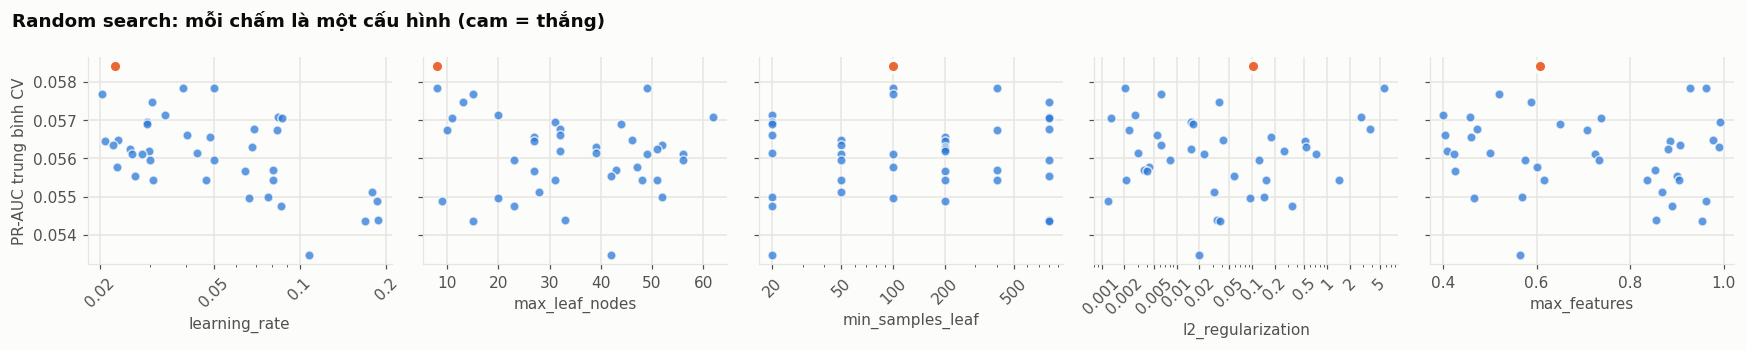

In [17]:
plots.plot_tuning(tuned.tuning_results_, ["learning_rate", "max_leaf_nodes", "min_samples_leaf",
                                          "l2_regularization", "max_features"]);

Đọc hình: điểm CV gần như phẳng trên một vùng rộng → **tối ưu "bằng phẳng"**, kết quả không nhạy với việc chọn chính xác
từng giá trị (tốt: mô hình ổn định). Điều rõ nhất là cấu hình tốt đều có `learning_rate` thấp và `min_samples_leaf`
không quá nhỏ — đúng như lý thuyết cho lớp dương hiếm.

### 8.3 Siêu tham số sau khi tune được lưu ở đâu — thuộc tính của chính đối tượng

`tune()` là phương thức của `BaseModel`, nên sau khi chạy **chính đối tượng mô hình** mang toàn bộ kết quả:

1. **Bộ tốt nhất được ghi đè vào các thuộc tính siêu tham số của chính nó** qua `self.set_params(**best)` —
   `tuned.learning_rate` giờ *là* giá trị tốt nhất, không phải giá trị mặc định;
2. **Bản ghi của quá trình tune** được lưu thành thuộc tính học được (đuôi `_`): `best_params_`, `best_score_`,
   `tuning_results_` (bảng mọi cấu hình đã thử), `tuning_space_`, `tuning_cv_`;
3. Mô hình được **train lại trên toàn bộ tập train** với bộ tốt nhất → `estimator_`, `n_iter_`.

In [18]:
hyper = pd.Series(tuned.get_hyperparams(), name="giá trị hiện hành").drop(["features"]).to_frame()
hyper["mặc định của lớp"] = pd.Series({k: v.default for k, v in inspect.signature(GBMModel).parameters.items()})
hyper["đã được tune?"] = hyper.index.isin(tuned.best_params_)
display(hyper)

assert all(getattr(tuned, k) == v for k, v in tuned.best_params_.items())
print("✔ mọi giá trị trong best_params_ đã nằm trong chính thuộc tính của đối tượng")

learned = {k: type(v).__name__ for k, v in vars(tuned).items() if k.endswith("_")}
print("\nThuộc tính học được (đuôi `_`):", learned)
print("n_iter_ (số cây thật sự dùng sau dừng sớm, thuộc tính HỌC ĐƯỢC):", tuned.n_iter_)

,giá trị hiện hành,mặc định của lớp,đã được tune?
categorical,"(category,)",(),False
class_weight,None,None,False
early_stopping,True,True,False
l2_regularization,0.1025,0.0000,True
learning_rate,0.0225,0.1000,True
max_bins,255,255,False
max_depth,None,None,True
max_features,0.6070,1.0000,True
max_iter,2000,500,False
max_leaf_nodes,8,31,True


✔ mọi giá trị trong best_params_ đã nằm trong chính thuộc tính của đối tượng

Thuộc tính học được (đuôi `_`): {'best_params_': 'dict', 'best_score_': 'float', 'tuning_results_': 'DataFrame', 'tuning_space_': 'dict', 'tuning_cv_': 'str', 'classes_': 'ndarray', 'feature_names_in_': 'ndarray', 'n_features_in_': 'int', 'estimator_': 'HistGradientBoostingClassifier'}
n_iter_ (số cây thật sự dùng sau dừng sớm, thuộc tính HỌC ĐƯỢC): 1531


**Ba hệ quả của thiết kế này** — cũng là ba câu trả lời khi được hỏi "làm sao tái lập mô hình":

In [19]:
# 1) clone() mang theo siêu tham số đã tune, nhưng KHÔNG mang trạng thái đã học
twin = clone(tuned)
print("clone: learning_rate =", twin.learning_rate, "| có best_params_?", hasattr(twin, "best_params_"),
      "| đã train?", hasattr(twin, "estimator_"))

# 2) save()/load() bằng joblib giữ NGUYÊN đối tượng — cả siêu tham số lẫn lịch sử tune
reloaded = GBMModel.load(ARTIFACT_DIR / "gbm_tuned.joblib")
print("load: best_params_ khớp?", reloaded.best_params_ == tuned.best_params_,
      "| tuning_results_ còn", len(reloaded.tuning_results_), "dòng")

# 3) export_hyperparams() ghi JSON đọc được bằng mắt — đưa thẳng vào báo cáo
print((ARTIFACT_DIR / "gbm_tuned.json").read_text(encoding="utf-8"))

clone: learning_rate = 0.022516907664967046 | có best_params_? False | đã train? False
load: best_params_ khớp? True | tuning_results_ còn 40 dòng
{
  "model": "GBMModel",
  "name": "hist_gbm",
  "params": {
    "categorical": [
      "category"
    ],
    "class_weight": null,
    "early_stopping": true,
    "features": [
      "lead_days",
      "delivered_hour",
      "delivered_weekend",
      "purchase_month",
      "purchase_weekday",
      "purchase_hour",
      "category",
      "is_tiki_trading",
      "log_price",
      "discount_rate",
      "prod_hist_n",
      "prod_hist_rate",
      "seller_hist_n",
      "seller_hist_rate",
      "cust_tenure_days",
      "cust_hist_n",
      "cust_hist_rate"
    ],
    "l2_regularization": 0.10249816559563214,
    "learning_rate": 0.022516907664967046,
    "max_bins": 255,
    "max_depth": null,
    "max_features": 0.6070427488160098,
    "max_iter": 2000,
    "max_leaf_nodes": 8,
    "min_samples_leaf": 100,
    "n_iter_no_change": 30,

**Logistic cũng được tune** (chỉ một siêu tham số `C` = 1/λ, cường độ phạt L2). `C` tối ưu rất nhỏ không có nghĩa là mô
hình bị phạt quá nặng: trong hàm mục tiêu của scikit-learn, `C` nhân với **tổng trọng số mẫu**
($\min_\beta \tfrac12\|\beta\|^2 + C\sum_i w_i\,\ell_i$), mà tổng trọng số khảo sát ~ quy mô quần thể (hàng trăm nghìn)
nên cường độ phạt *hiệu dụng* vẫn vừa phải.

In [20]:
print("Logistic best_params_:", tuned_lr.best_params_, "· best_score_ (PR-AUC CV):", round(tuned_lr.best_score_, 4))
print("GBM      best_params_:", tuned.best_params_, "· best_score_ (PR-AUC CV):", round(tuned.best_score_, 4))

Logistic best_params_: {'C': 1.879466824163847e-05} · best_score_ (PR-AUC CV): 0.0566
GBM      best_params_: {'l2_regularization': 0.10249816559563214, 'learning_rate': 0.022516907664967046, 'max_depth': None, 'max_features': 0.6070427488160098, 'max_leaf_nodes': 8, 'min_samples_leaf': 100} · best_score_ (PR-AUC CV): 0.0584


> ⚠️ `best_score_` là điểm của cấu hình **thắng trong 40 ứng viên** trên chính các fold dùng để chọn — nó **lạc quan**
> (lời nguyền người thắng: lấy max của nhiều ước lượng nhiễu thì kỳ vọng của max lớn hơn giá trị thật). Ước lượng không
> chệch của hiệu năng tương lai chỉ có ở tập test (§11).

## 9. Chọn mô hình cuối

Sau khi tune, còn hai ứng viên mạnh (GBM, logistic) và một phương án kết hợp: **ensemble trung bình xác suất** của hai
mô hình. Quy tắc chọn đặt trước: **điểm CV trung bình cao nhất**, trên đúng các fold và siêu tham số đã tune.

**Vì sao ensemble có lý do lý thuyết để thắng.** Với dự báo trung bình $\bar f = \tfrac12(f_1 + f_2)$, phân rã
"ambiguity" (Krogh & Vedelsby, 1995) cho:

$$\big(\bar f - y\big)^2 = \tfrac12\big[(f_1-y)^2 + (f_2-y)^2\big] - \tfrac14\big(f_1 - f_2\big)^2$$

Sai số của trung bình = trung bình sai số riêng **trừ** độ bất đồng giữa hai mô hình. GBM và logistic sai theo hai kiểu
khác nhau — cây học được tương tác nhưng **không ngoại suy** ra ngoài miền đã thấy (một lá là hằng số); logistic ngoại
suy tuyến tính mượt nhưng bỏ sót tương tác — nên độ bất đồng lớn, đặc biệt khi dữ liệu tương lai trôi khỏi miền train
(ví dụ `prod_hist_n` tăng dần theo năm vì sản phẩm tích luỹ review).

In [21]:
candidates = final_candidates(train, tuned, tuned_lr, scheme)
candidates

,val_2022,val_2023,mean
ứng viên,,,
GBM tuned,0.0662,0.0506,0.0584
logistic tuned,0.0627,0.0505,0.0566
ensemble GBM + logistic,0.0662,0.0516,0.0589


> **Ghi chú minh bạch.** Ensemble đã được chấm CV *trước* lần chạy thử đầu tiên trên test và khi đó bị gạt đi vì chênh
> lệch nhỏ. Nó được đưa lại vào danh sách ứng viên *sau* khi lần chạy thử cho thấy logistic tốt hơn GBM trên test. Quy
> tắc chọn (CV cao nhất) không đổi, nhưng tập ứng viên được mở rộng sau khi đã nhìn test — vì vậy điểm test của mô hình
> chốt nên được đọc là **hơi lạc quan**. Điểm test của mọi mô hình khác (M0–M5) không bị ảnh hưởng.

Mô hình chốt **M7 = `CalibratedModel(EnsembleModel(GBM tuned, logistic tuned))`** — một Decorator bọc một Composite bọc
hai mô hình lá, và vòng đánh giá dùng nó y hệt như `PriorBaseline`.

## 10. Hiệu chỉnh xác suất (C12)

**Vì sao xác suất thô không dùng được.** Hai nguồn lệch cộng dồn: (1) train với `survey_balanced` — lớp dương được nhân
lên cho bằng lớp âm nên mô hình "tin" prior 50%; (2) trôi dạt — tỉ lệ review xấu giảm qua các năm (§2). Mô hình vẫn
**xếp hạng** tốt, nhưng nói "30%" ở chỗ thực tế là 2%.

**Cách làm (`CalibratedModel`, tinh thần của `CalibratedClassifierCV` nhưng chia theo thời gian):**
1. train bản sao mô hình trên các năm ≤2022;
2. dự báo năm 2023 (dữ liệu nó chưa thấy);
3. học ánh xạ điểm → xác suất trên năm 2023, **có trọng số khảo sát** → xác suất *quần thể* của năm gần nhất;
4. train lại mô hình trên toàn bộ ≤2023, giữ ánh xạ ở bước 3.

**Platt scaling:** $p = \sigma\big(a\cdot\text{logit}(s) + b\big)$. Nếu lệch chỉ do prior khác nhau thì lý thuyết cho
**$a = 1$** và $b = \log\frac{\pi_{\text{thật}}}{1-\pi_{\text{thật}}} - \log\frac{\pi_{\text{train}}}{1-\pi_{\text{train}}}$
(hiệu chỉnh prior-shift, Bayes). $a<1$ = mô hình tự tin quá mức, $a>1$ = rụt rè. Platt (2 tham số) được chọn trước
thay cho isotonic (hàm bậc thang tự do, dễ quá khớp) vì năm 2023 chỉ có khoảng một nghìn ca dương.

Cả hai phép hiệu chỉnh đều **đơn điệu tăng** → không đổi thứ tự → **PR-AUC giữ nguyên**, chỉ Brier, log-loss, ECE đổi.

In [22]:
ladder = build_ladder(tuned, tuned_lr)
preds = fit_ladder(ladder, train, test, scheme)          # bước nặng nhất: train toàn bộ thang mô hình
final = ladder[FINAL_MODEL]
print(f"Platt: a = {final.calibration_slope_:.3f} · b = {final.calibration_intercept_:.3f} "
      f"· học trên {final.n_calibration_:,} dòng năm {final.calib_year}")

Platt: a = 1.262 · b = -3.169 · học trên 26,591 dòng năm 2023


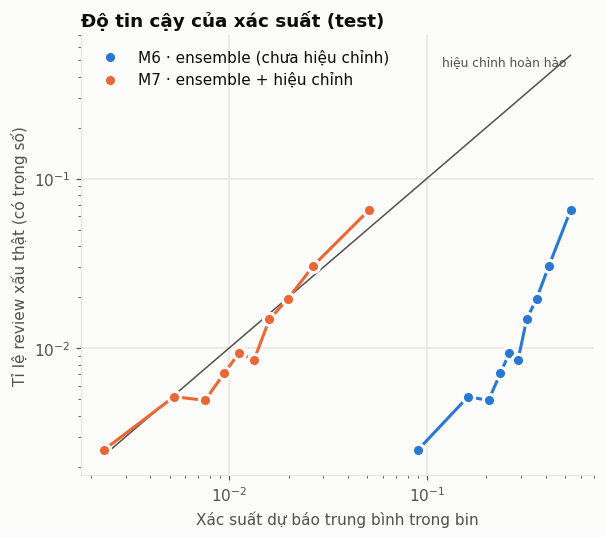

In [23]:
y_te, w_te = test[TARGET].to_numpy(), test[WEIGHT].to_numpy()
plots.plot_reliability(y_te, {"M6 · ensemble (chưa hiệu chỉnh)": preds["M6 · ensemble GBM + logistic"].to_numpy(),
                              "M7 · ensemble + hiệu chỉnh": preds[FINAL_MODEL].to_numpy()}, w_te);

Đường gần vạch chéo = xác suất đáng tin: trong nhóm đơn mô hình nói "4%", thực tế có ~4% review xấu. Bảng số tương ứng
(ECE, Brier) ở §11.

## 11. Kết quả trên tập test 2024–2026 (C6, C11) — chấm một lần

### 11.1 Metric nào, vì sao

* **Accuracy bị loại**: đoán "không bao giờ có review xấu" đã đạt ~98% trên quần thể (xem ô dưới) mà không có giá trị gì.
* **PR-AUC (average precision)** — metric chính: diện tích dưới đường precision–recall, tập trung vào lớp hiếm. Mốc
  ngẫu nhiên = **tỉ lệ dương** (không phải 0,5). Vì mỗi tập chấm có tỉ lệ dương khác nhau, ta so bằng **lift** =
  PR-AUC ÷ tỉ lệ dương ("tốt hơn ngẫu nhiên bao nhiêu lần").
* **ROC-AUC** — chỉ ghi kèm: trên dữ liệu lệch, số âm khổng lồ làm FPR luôn nhỏ nên ROC trông đẹp giả (Saito &
  Rehmsmeier, 2015).
* **Brier score** $= \frac{\sum w_i (p_i - y_i)^2}{\sum w_i}$ và **Brier skill** $= 1 - \text{Brier}/\text{Brier}_{\text{ref}}$
  với tham chiếu = dự báo hằng số bằng đúng tỉ lệ dương của tập test (tham chiếu mạnh nhất một hằng số có thể đạt).
  Skill > 0 mới là hơn "đoán tỉ lệ chung". Brier đo *cả* xếp hạng *lẫn* hiệu chỉnh — chỉ mô hình đã hiệu chỉnh mới có
  Brier có nghĩa.
* **ECE** — sai lệch trung bình giữa xác suất dự báo và tỉ lệ thật theo bin.
* **Precision / recall @5%** — câu hỏi vận hành: *nếu CSKH chỉ gọi cho 5% đơn rủi ro nhất thì bắt được bao nhiêu phần
  trăm review xấu, và bao nhiêu cuộc gọi là trúng?*

In [24]:
prev = np.average(y_te, weights=w_te)
print(f"Tỉ lệ review xấu trên test (quần thể): {prev:.4f} → accuracy của 'luôn đoán không': {1 - prev:.2%}")
table = evaluation_table(preds, test)
cols = ["pr_auc", "lift_pr_auc", "roc_auc", "brier_skill", "ece", "precision@5%", "recall@5%", "p_mean", "prevalence"]
for set_name, sub in table.groupby("tập", sort=False):
    display(Markdown(f"**{set_name}** — n = {sub['n'].iloc[0]:,}"))
    display(sub.set_index("mô hình")[cols])

Tỉ lệ review xấu trên test (quần thể): 0.0168 → accuracy của 'luôn đoán không': 98.32%


**toàn bộ test (có trọng số)** — n = 41,182

,pr_auc,lift_pr_auc,roc_auc,brier_skill,ece,precision@5%,recall@5%,p_mean,prevalence
mô hình,,,,,,,,,
M0 · tỉ lệ chung,0.0168,1.0000,0.5000,-0.0464,0.0277,0.0190,0.0567,0.0445,0.0168
M1a · chỉ sla_breach,0.0179,1.0634,0.5147,-13.2124,0.4664,0.0268,0.0799,0.4832,0.0168
M1b · chỉ lead_days (spline),0.0244,1.4520,0.5772,-12.3758,0.4467,0.0353,0.1051,0.4635,0.0168
M2 · logistic tuned,0.0641,3.8200,0.7485,-5.3401,0.2828,0.0778,0.2314,0.2995,0.0168
M3 · random forest,0.0487,2.8977,0.6933,-2.8528,0.2021,0.0642,0.1911,0.2189,0.0168
M4 · GBM mặc định,0.0582,3.4655,0.7454,-4.1965,0.2303,0.0754,0.2246,0.2471,0.0168
M5 · GBM tuned,0.0548,3.2658,0.7468,-5.2123,0.2588,0.0722,0.2150,0.2756,0.0168
M6 · ensemble GBM + logistic,0.0632,3.7627,0.7585,-5.1187,0.2708,0.0784,0.2334,0.2876,0.0168
M7 · ensemble + hiệu chỉnh (CHỐT),0.0632,3.7627,0.7585,0.0218,0.0032,0.0784,0.2334,0.0163,0.0168


**sản phẩm vét cạn (không lấy mẫu)** — n = 24,626

,pr_auc,lift_pr_auc,roc_auc,brier_skill,ece,precision@5%,recall@5%,p_mean,prevalence
mô hình,,,,,,,,,
M0 · tỉ lệ chung,0.0371,1.0000,0.5000,-0.0015,0.0074,0.0325,0.0438,0.0445,0.0371
M1a · chỉ sla_breach,0.0387,1.0428,0.5134,-5.6656,0.4488,0.0487,0.0657,0.4858,0.0371
M1b · chỉ lead_days (spline),0.0481,1.2962,0.5677,-5.5242,0.4386,0.0609,0.0821,0.4756,0.0371
M2 · logistic tuned,0.0856,2.3100,0.6842,-3.3645,0.3321,0.1015,0.1369,0.3692,0.0371
M3 · random forest,0.0785,2.1177,0.6723,-1.3556,0.2091,0.0991,0.1336,0.2462,0.0371
M4 · GBM mặc định,0.0769,2.0744,0.6805,-3.3060,0.3183,0.1007,0.1358,0.3554,0.0371
M5 · GBM tuned,0.0740,1.9962,0.6729,-3.9698,0.3510,0.0999,0.1347,0.3881,0.0371
M6 · ensemble GBM + logistic,0.0823,2.2206,0.6884,-3.5917,0.3415,0.1032,0.1391,0.3786,0.0371
M7 · ensemble + hiệu chỉnh (CHỐT),0.0823,2.2206,0.6884,0.0157,0.0100,0.1032,0.1391,0.0271,0.0371


**có nhãn khách (2024+)** — n = 11,287

,pr_auc,lift_pr_auc,roc_auc,brier_skill,ece,precision@5%,recall@5%,p_mean,prevalence
mô hình,,,,,,,,,
M0 · tỉ lệ chung,0.0193,1.0000,0.5000,-0.0336,0.0252,0.0171,0.0440,0.0445,0.0193
M1a · chỉ sla_breach,0.0211,1.0940,0.5179,-11.3761,0.4633,0.0316,0.0820,0.4826,0.0193
M1b · chỉ lead_days (spline),0.0291,1.5106,0.5810,-10.5714,0.4421,0.0478,0.1240,0.4614,0.0193
M2 · logistic tuned,0.0719,3.7301,0.7450,-4.3221,0.2723,0.0857,0.2220,0.2915,0.0193
M3 · random forest,0.0520,2.6985,0.6984,-2.3625,0.1968,0.0705,0.1820,0.2160,0.0193
M4 · GBM mặc định,0.0646,3.3522,0.7510,-3.2750,0.2177,0.0864,0.2240,0.2370,0.0193
M5 · GBM tuned,0.0645,3.3438,0.7606,-4.1582,0.2474,0.0795,0.2060,0.2667,0.0193
M6 · ensemble GBM + logistic,0.0719,3.7281,0.7669,-4.1056,0.2598,0.0887,0.2300,0.2791,0.0193
M7 · ensemble + hiệu chỉnh (CHỐT),0.0719,3.7281,0.7669,0.0217,0.0050,0.0887,0.2300,0.0154,0.0193


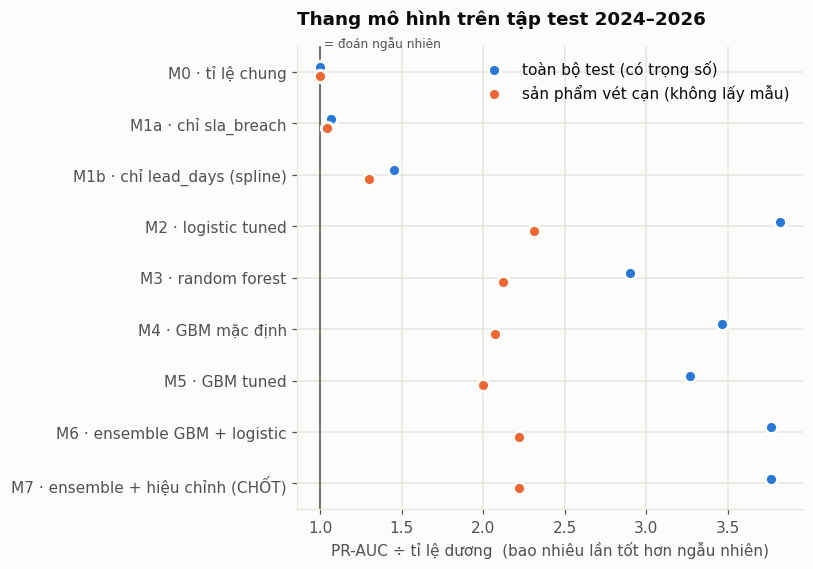

In [25]:
plots.plot_lift(table[~table["mô hình"].str.startswith("M8")],
                ["toàn bộ test (có trọng số)", "sản phẩm vét cạn (không lấy mẫu)"]);

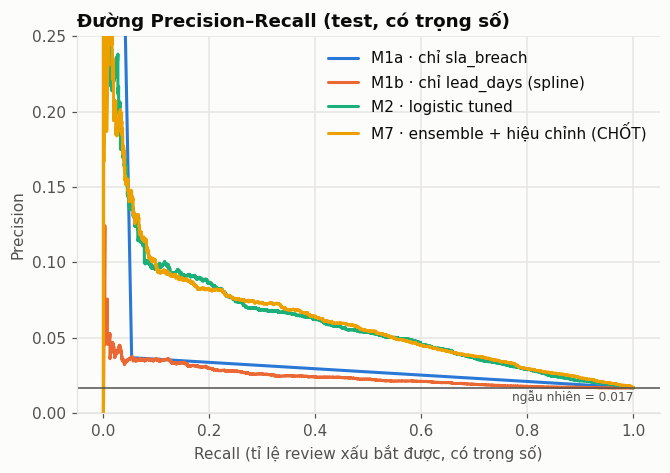

In [26]:
plots.plot_pr_curves(y_te, {k: preds[k].to_numpy() for k in
                            ["M1a · chỉ sla_breach", "M1b · chỉ lead_days (spline)", "M2 · logistic tuned", FINAL_MODEL]},
                     w_te);

### 11.2 Khác biệt có thật hay do may? — bootstrap ghép cặp theo cụm (tầng 5)

Với mỗi cặp mô hình (a, b): lấy lại **sản phẩm** có hoàn lại (không phải lấy lại từng dòng — review cùng sản phẩm không
độc lập: cùng hàng, cùng kho, cùng nhà bán), chấm **cả hai** mô hình trên **cùng** mẫu lấy lại, ghi chênh lệch PR-AUC;
lặp lại N_BOOT lần → khoảng tin cậy 95% theo phân vị. *Ghép cặp* triệt tiêu phần nhiễu chung ("tập test dễ hay khó"),
nên KTC của chênh lệch hẹp hơn nhiều so với việc so hai KTC riêng. KTC không chứa 0 → khác biệt có ý nghĩa.

ΔPR-AUC (M7 · ensemble + hiệu chỉnh (CHỐT) − M2 · logistic tuned): -0.0010 [-0.0043, 0.0026] (95% CI, n=41,182, n_eff=13100, cụm=2,252)
ΔPR-AUC (M7 · ensemble + hiệu chỉnh (CHỐT) − M5 · GBM tuned): 0.0083 [0.0052, 0.0128] (95% CI, n=41,182, n_eff=13100, cụm=2,252)
ΔPR-AUC (M5 · GBM tuned − M4 · GBM mặc định): -0.0034 [-0.0078, 0.0002] (95% CI, n=41,182, n_eff=13100, cụm=2,252)
ΔPR-AUC (M7 · ensemble + hiệu chỉnh (CHỐT) − M1b · chỉ lead_days (spline)): 0.0388 [0.0318, 0.0486] (95% CI, n=41,182, n_eff=13100, cụm=2,252)
ΔPR-AUC (M1b · chỉ lead_days (spline) − M1a · chỉ sla_breach): 0.0065 [0.0050, 0.0093] (95% CI, n=41,182, n_eff=13100, cụm=2,252)


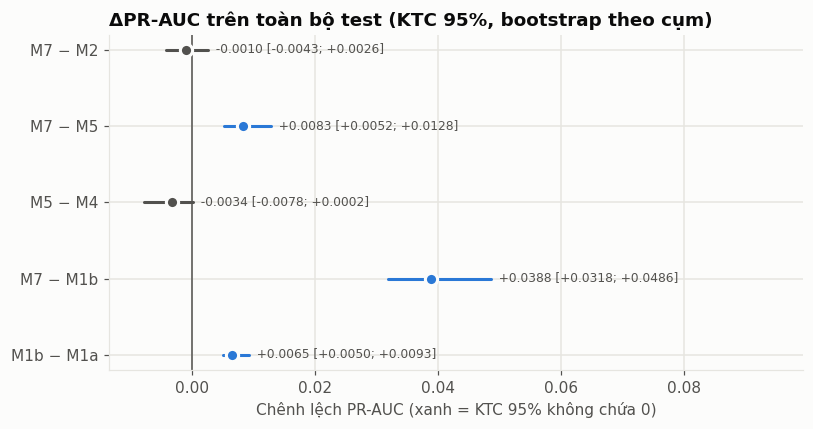

In [27]:
test_cmp = paired_comparisons(preds, test, TEST_PAIRS, n_boot=N_BOOT)
for e in test_cmp:
    print(e)
plots.plot_forest(test_cmp, "ΔPR-AUC trên toàn bộ test (KTC 95%, bootstrap theo cụm)");

**Đọc kết quả §11.**
1. **Chỉ báo SLA một mình gần như không có giá trị dự báo**: M1a có lift ≈ 1 — ngang đoán ngẫu nhiên — trên cả ba tập.
   `lead_days` liên tục (M1b) hơn M1a có ý nghĩa thống kê: nhị phân hoá ở ngưỡng 5 ngày **vứt bỏ** thông tin.
2. **Mô hình đầy đủ tốt hơn ngẫu nhiên ~3–4 lần** trên toàn bộ test và ~2 lần trên tập sản phẩm vét cạn (tỉ lệ dương ở
   đó cao hơn nên lift tự nhiên thấp hơn). **Thứ tự các mô hình giống nhau trên hai tập** → kết luận không phụ thuộc
   giả định trọng số.
3. **Tune thắng trên CV nhưng không thắng trên test** (M5 vs M4, KTC chứa 0) — đúng cảnh báo ở §8: điểm CV của cấu hình
   thắng là lạc quan, và các fold 2022/2023 không giống hệt 2024–2026. GBM tuned đứng một mình thấp hơn logistic tuned;
   ensemble kéo lại ngang logistic (KTC chứa 0) và **hơn GBM tuned có ý nghĩa** — đúng vai trò "bảo hiểm" của ensemble.
4. **Mô hình chốt M7 hiệu chỉnh tốt**: xác suất trung bình ≈ tỉ lệ thật, ECE rất nhỏ, và là mô hình **duy nhất** trong
   thang có Brier skill dương — các mô hình khác hoặc là hằng số (M0) hoặc train với trọng số cân bằng lớp (xác suất phồng).
5. **Ý nghĩa vận hành**: gọi cho 5% đơn rủi ro nhất bắt được khoảng một phần tư số review xấu, tỉ lệ trúng gấp ~4–5 lần
   gọi ngẫu nhiên.

## 12. Ablation trung tâm C9 — SLA vs lead time vs lời khách

Đây là phép chứng minh lại kết luận `FINDINGS.md` §4 bằng một phương pháp độc lập. Ba mô hình **một biến**, không được
gộp (vì `sla_breach` là hàm của `lead_days` — §3):

| Mô hình | Chỉ dùng | Đại diện cho |
|---|---|---|
| M1a | `sla_breach` (nhị phân, ngưỡng 5 ngày) | **cách doanh nghiệp đang đo** |
| M1b | `lead_days` (spline bậc 3) | toàn bộ thông tin về thời gian giao |
| M1c | `customer_says_late` (khách tự báo) | thứ khách thật sự cảm nhận |
| M1d | `lead_days` + `customer_says_late` | lời khách có thêm thông tin *ngoài* thời gian giao không? |

Tất cả chấm trên **cùng** tập test có nhãn khách (2024–2026) → so sánh ghép cặp. Với mô hình một biến, thứ hạng chỉ phụ
thuộc chính biến đó, nên PR-AUC ở đây đo đúng **lượng thông tin về sự bất mãn mà mỗi chỉ báo mang theo** — không phụ
thuộc chất lượng huấn luyện. Train bằng trọng số khảo sát thuần để xác suất là xác suất quần thể.

,pr_auc,lift_pr_auc,roc_auc,brier_skill,precision@5%,recall@5%,prevalence,n
mô hình,,,,,,,,
M1a · sla_breach (doanh nghiệp đo),0.0211,1.0940,0.5179,-0.0259,0.0316,0.0820,0.0193,11287
M1b · lead_days (thông tin đầy đủ),0.0291,1.5104,0.5809,-0.0223,0.0478,0.1240,0.0193,11287
M1c · khách nói trễ (khách cảm nhận),0.0292,1.5144,0.5503,0.0080,0.0556,0.1440,0.0193,11287
M1d · lead_days + khách nói trễ,0.0486,2.5209,0.6129,0.0079,0.0648,0.1680,0.0193,11287


ΔPR-AUC (M1b · lead_days (thông tin đầy đủ) − M1a · sla_breach (doanh nghiệp đo)): 0.0080 [0.0052, 0.0127] (95% CI, n=11,287, n_eff=3270, cụm=1,768)
ΔPR-AUC (M1c · khách nói trễ (khách cảm nhận) − M1a · sla_breach (doanh nghiệp đo)): 0.0081 [0.0034, 0.0151] (95% CI, n=11,287, n_eff=3270, cụm=1,768)
ΔPR-AUC (M1d · lead_days + khách nói trễ − M1b · lead_days (thông tin đầy đủ)): 0.0195 [0.0109, 0.0342] (95% CI, n=11,287, n_eff=3270, cụm=1,768)


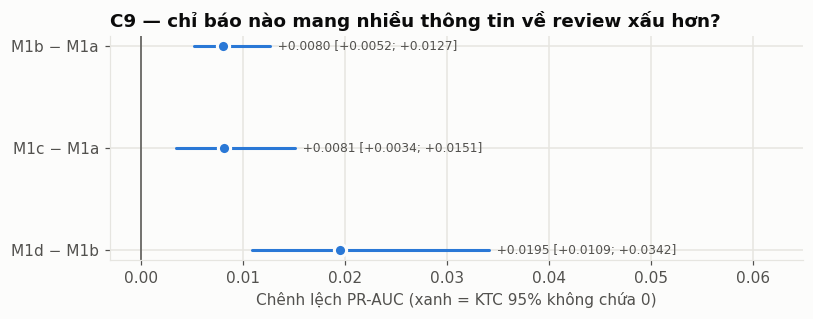

In [28]:
c9_preds, labelled = fit_c9(train, test, C9_SCHEME)
c9_table = evaluation_table(c9_preds, labelled)
c9_table = c9_table[c9_table["tập"].str.startswith("toàn bộ")].set_index("mô hình")
display(c9_table[["pr_auc", "lift_pr_auc", "roc_auc", "brier_skill", "precision@5%", "recall@5%", "prevalence", "n"]])
c9_cmp = paired_comparisons(c9_preds, labelled, C9_PAIRS, n_boot=N_BOOT)
for e in c9_cmp:
    print(e)
plots.plot_forest(c9_cmp, "C9 — chỉ báo nào mang nhiều thông tin về review xấu hơn?");

**Đọc kết quả C9 — kết luận `FINDINGS.md` §4 được chứng minh lần hai, bằng một phương pháp độc lập.**
* **Cách doanh nghiệp đang đo (M1a)** gần như không phân biệt được review xấu: lift ≈ 1 và Brier skill **âm** — tệ hơn
  cả việc đoán tỉ lệ chung cho mọi đơn.
* Thông tin về thời gian **vẫn có** trong dữ liệu (M1b hơn M1a có ý nghĩa) — nó bị vứt đi khi nén thành "đạt/không đạt".
* **Lời khách tự báo (M1c)** mang lượng thông tin ngang `lead_days`, và **gộp hai nguồn (M1d) tốt hơn hẳn từng nguồn**
  (KTC của M1d − M1b không chứa 0): lời khách chứa thông tin *không có* trong đồng hồ giao hàng — kỳ vọng riêng, lời hứa
  cụ thể lúc đặt hàng, trải nghiệm với shipper.
* So sánh trung bình (§4) và so sánh sức dự đoán (C9) cho **cùng một câu trả lời**.

**Tầng ex-post: thêm mọi tín hiệu khách tự khai vào mô hình đầy đủ (M8 vs M5, cùng họ GBM, cùng siêu tham số).** Đây
không phải mô hình dự báo (tín hiệu có cùng lúc với số sao) — nó đo *trần thông tin*: khi đã biết khách nói gì về giao
hàng và có đính kèm ảnh hay không, khả năng giải thích review xấu tăng bao nhiêu.

In [29]:
lab = test["has_customer_label"].to_numpy()
expost_cmp = paired_comparisons(preds[lab], test[lab], EXPOST_PAIR, n_boot=N_BOOT)
print(expost_cmp[0])

ΔPR-AUC (M8 · GBM tuned + tín hiệu khách (ex-post) − M5 · GBM tuned): 0.2099 [0.1614, 0.2651] (95% CI, n=11,287, n_eff=3270, cụm=1,768)


Mức tăng khi thêm tín hiệu khách (M8 − M5) lớn hơn rất nhiều so với phần mà riêng nhãn trễ hẹn đóng góp ở C9 — nên nó
**không thể chỉ đến từ thời gian giao**: phần lớn đến từ các tín hiệu khác cùng lúc với số sao (ảnh đính kèm, đóng gói,
thái độ shipper, độ trễ viết review). Sự bất mãn nằm ở **trải nghiệm tổng thể** — thứ một chỉ số thời gian như SLA
không bao giờ đo được. (M8 là mô hình giải thích, không dùng để dự báo.)

## 13. Nhóm feature nào thật sự mang thông tin (tầng 7)

Hai công cụ bổ sung cho nhau:

* **Ablation theo nhóm** — bỏ hẳn một nhóm, **train lại** (giữ siêu tham số), đo PR-AUC mất bao nhiêu. Trả lời "nhóm này
  có mang thông tin *không thay thế được* bởi các nhóm khác không". Dùng `with_features()` — đa hình, chạy được cho cả
  ensemble.
* **Permutation importance** — không train lại; xáo trộn một cột trên test, đo PR-AUC tụt. Nhanh, theo từng feature,
  nhưng chia điểm cho các feature tương quan. Không dùng `feature_importances_` kiểu impurity của cây vì nó thiên vị
  feature nhiều giá trị và đo trên tập train.

,số feature,toàn bộ test (có trọng số),sản phẩm vét cạn (không lấy mẫu),Δ toàn bộ test (có trọng số),Δ sản phẩm vét cạn (không lấy mẫu)
biến thể,,,,,
(đầy đủ),17,0.0632,0.0823,0.0000,0.0000
bỏ giao_hang,14,0.0619,0.0806,-0.0013,-0.0017
bỏ thoi_diem_mua,14,0.0647,0.0840,0.0015,0.0016
bỏ san_pham,13,0.0616,0.0803,-0.0016,-0.0021
bỏ lich_su_san_pham,15,0.0529,0.0793,-0.0103,-0.0030
bỏ lich_su_nha_ban,15,0.0628,0.0836,-0.0004,0.0013
bỏ khach_hang,14,0.0561,0.0690,-0.0071,-0.0134


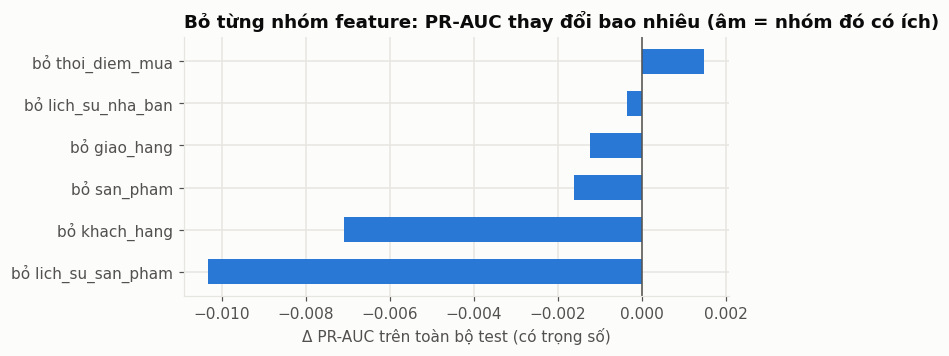

In [30]:
ensemble = ladder["M6 · ensemble GBM + logistic"]
ablation = group_ablation(ensemble, EX_ANTE_FEATURES, train, test, scheme)
display(ablation)
plots.plot_hbar(ablation.drop("(đầy đủ)")["Δ toàn bộ test (có trọng số)"],
                "Bỏ từng nhóm feature: PR-AUC thay đổi bao nhiêu (âm = nhóm đó có ích)",
                "Δ PR-AUC trên toàn bộ test (có trọng số)");

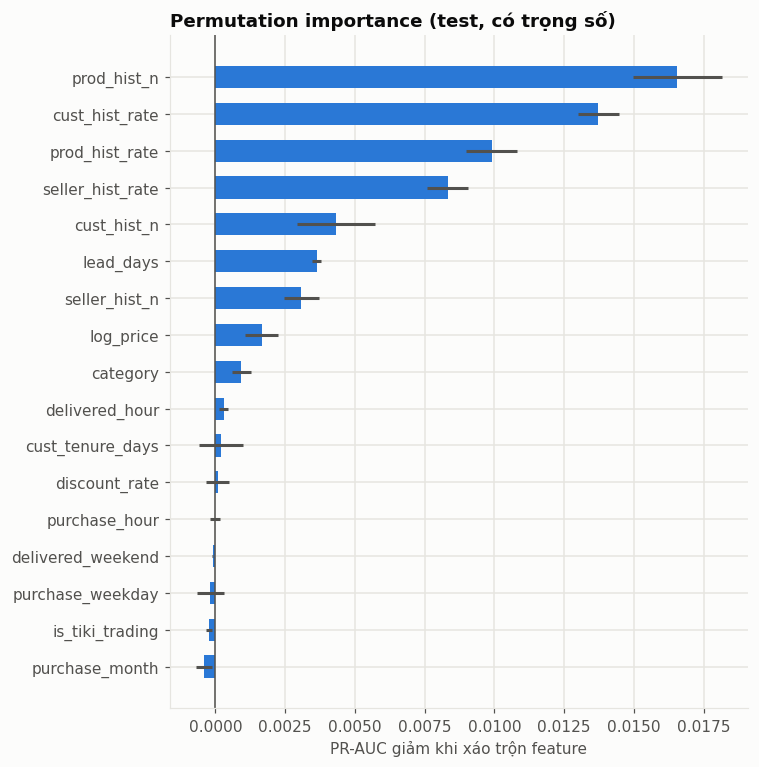

In [31]:
importance = permutation_importance_table(ensemble, test, EX_ANTE_FEATURES)
plots.plot_hbar(importance.set_index("feature")["giảm_pr_auc"], "Permutation importance (test, có trọng số)",
                "PR-AUC giảm khi xáo trộn feature", errors=importance.set_index("feature")["độ_lệch_chuẩn"]);

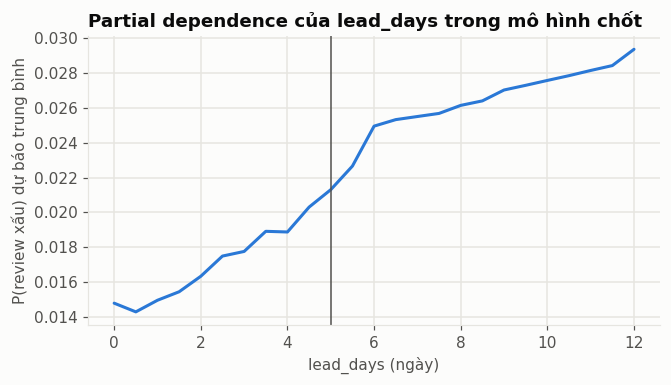

In [32]:
grid = np.linspace(0, 12, 25)
pdp = partial_dependence(final, test, "lead_days", grid, w_te)
plots.plot_line(pdp, "lead_days", "rủi_ro_dự_báo", "Partial dependence của lead_days trong mô hình chốt",
                "lead_days (ngày)", "P(review xấu) dự báo trung bình", vline=5);

**Đọc kết quả §13.** Hai nhóm quan trọng nhất là **lịch sử khách hàng** và **lịch sử sản phẩm** — bỏ đi thì PR-AUC tụt
nhiều nhất, trên cả hai tập chấm. Nhóm giao hàng đóng góp nhỏ nhưng nhất quán (âm trên cả hai tập). Nhóm thời điểm mua
không có ích — bỏ đi còn tốt lên chút ít, dấu hiệu feature nhiễu. Trong chế độ vận hành hiện tại, **ai mua và mua gì**
dự báo review xấu tốt hơn nhiều so với **giao nhanh hay chậm** — một lý do nữa để không dùng một chỉ số thời gian làm
thước đo chính của trải nghiệm khách hàng.

## 14. Phân tích lỗi và câu hỏi về năm 2021 (C13)

### 14.1 Mô hình chốt tốt/kém ở phân khúc nào

`xác_suất_TB` so với `tỉ_lệ_thật` = hiệu chỉnh "trên toàn khối" của phân khúc; `pr_auc`/`lift` = khả năng xếp hạng bên
trong phân khúc. Phân khúc dưới 30 ca dương bị gắn ⚠️ — PR-AUC ở đó chỉ là nhiễu.

In [33]:
p_final = preds[FINAL_MODEL].to_numpy()
seg_test = test.assign(
    nhom_nha_ban=np.where(test["is_tiki_trading"] == 1, "Tiki Trading", "Bên thứ ba"),
    lead_bin=pd.cut(test["lead_days"], [0, 1, 2, 3, 5, 10, 90], include_lowest=True))
for col in (YEAR, "nhom_nha_ban", "lead_bin", "category_name"):
    display(Markdown(f"**Theo `{col}`**"))
    display(segment_report(seg_test, p_final, col))

**Theo `year`**

,n,n_dương,n_eff,tỉ_lệ_thật,xác_suất_TB,pr_auc,lift,cờ
year,,,,,,,,
2024,18369,665,"6,371.1136",0.0166,0.0169,0.0555,3.3433,
2025,14458,509,"4,353.2364",0.0168,0.0161,0.0639,3.8002,
2026,8355,291,"2,411.4321",0.0172,0.0152,0.1011,5.8794,


**Theo `nhom_nha_ban`**

,n,n_dương,n_eff,tỉ_lệ_thật,xác_suất_TB,pr_auc,lift,cờ
nhom_nha_ban,,,,,,,,
Bên thứ ba,11236,589,"7,635.3130",0.0434,0.0293,0.0956,2.2011,
Tiki Trading,29946,876,"9,747.0674",0.0119,0.0139,0.0395,3.3260,


**Theo `lead_bin`**

,n,n_dương,n_eff,tỉ_lệ_thật,xác_suất_TB,pr_auc,lift,cờ
lead_bin,,,,,,,,
"(-0.001, 1.0]",18721,540,"6,228.7486",0.0129,0.0135,0.0421,3.2688,
"(1.0, 2.0]",10831,389,"3,304.7820",0.0165,0.0158,0.0611,3.7111,
"(2.0, 3.0]",5694,237,"1,761.2591",0.0207,0.0189,0.0722,3.4930,
"(3.0, 5.0]",4638,221,"1,542.6760",0.0274,0.0237,0.0847,3.0953,
"(5.0, 10.0]",1137,66,414.2819,0.0352,0.0339,0.1214,3.4465,
"(10.0, 90.0]",161,12,14.6023,0.0487,0.0424,0.2522,5.1751,⚠️ ít ca dương


**Theo `category_name`**

,n,n_dương,n_eff,tỉ_lệ_thật,xác_suất_TB,pr_auc,lift,cờ
category_name,,,,,,,,
Bách hóa online,5,0,5.0000,0.0000,0.0365,NaN,NaN,⚠️ ít ca dương
Làm đẹp - Sức khỏe,4554,258,"1,765.6178",0.0374,0.0243,0.0842,2.2534,
Mẹ và bé,4362,179,"2,116.0764",0.0257,0.0195,0.0770,3.0017,
Nhà cửa - Đời sống,20774,592,"6,605.2530",0.0111,0.0135,0.0373,3.3713,
Nhà sách tiki,1028,67,636.7649,0.0346,0.0213,0.1667,4.8232,
Sách tiếng Việt,4525,207,"1,221.0988",0.0227,0.0216,0.0882,3.8947,
Thể thao - Dã ngoại,335,21,335.0000,0.0627,0.0478,0.0700,1.1167,⚠️ ít ca dương
Thời trang nữ,4026,92,"2,136.0085",0.0156,0.0149,0.0432,2.7611,
Điện gia dụng,1340,48,791.6621,0.0204,0.0224,0.0573,2.8104,


### 14.2 Khi giao hàng thật sự trễ trên diện rộng, lead time có ăn vào rating không?

2021 (giãn cách xã hội) là chế độ vận hành duy nhất trong dữ liệu có tỉ lệ vượt SLA hai chữ số. So đường
$P(\text{review xấu} \mid \text{lead\_days})$ giữa các kỷ nguyên — logistic spline, trọng số khảo sát. Bảng phải là
**rủi ro tương đối** (so với giao trong 1 ngày) vì mức tuyệt đối giữa các năm bị ảnh hưởng bởi thiên lệch thời gian của
tầng 5★ (§2) và trôi dạt; *hình dạng* đường cong trong một kỷ nguyên thì không.

kỷ nguyên,2021 (giãn cách),2022–2023,2024–2026
lead_days,,,
1.0000,1.0000,1.0000,1.0000
3.0000,1.4269,1.7755,1.9798
5.0000,1.5577,2.1158,2.1047
7.0000,1.6428,2.4901,2.2292
10.0000,1.7697,3.1087,2.4136


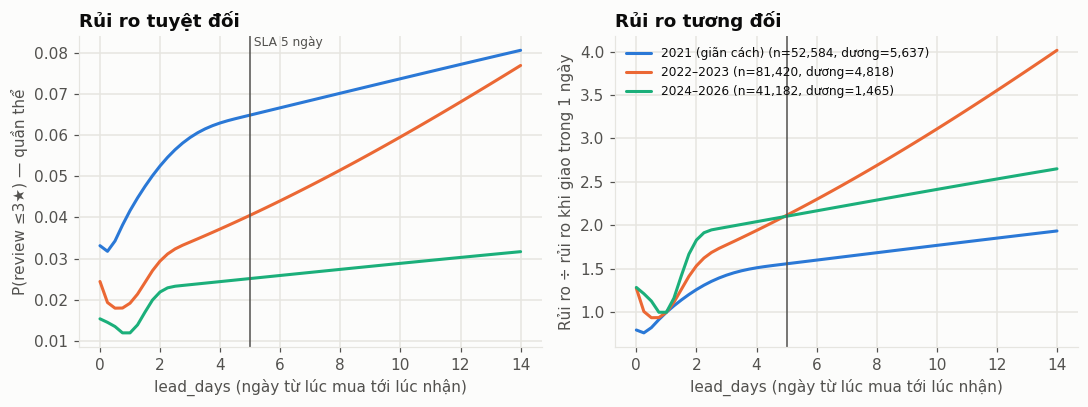

In [34]:
eras = {"2021 (giãn cách)": (frame[YEAR] == 2021).to_numpy(),
        "2022–2023": frame[YEAR].between(2022, 2023).to_numpy(),
        "2024–2026": (frame[YEAR] >= 2024).to_numpy()}
curves = dose_response_by_era(frame, eras, np.linspace(0, 14, 57))
plots.plot_dose_response(curves);
curves[curves["lead_days"].isin([1.0, 3.0, 5.0, 7.0, 10.0])].pivot(
    index="lead_days", columns="kỷ nguyên", values="rủi_ro_tương_đối")

**Trả lời câu hỏi C13.**
* Ở mọi kỷ nguyên, rủi ro review xấu tăng theo thời gian giao. Ở **2024–2026, phần lớn mức tăng xảy ra trong vài ngày
  đầu — bên trong ngưỡng SLA**: giao mất 3 ngày đã có rủi ro gần gấp đôi giao trong 1 ngày, trong khi SLA vẫn tính đơn đó
  là "đạt"; còn quanh mốc 5 ngày đường cong đã gần phẳng. **Ngưỡng SLA đặt ở chỗ tác hại đã xảy ra xong.**
* **Phát hiện phản trực giác:** 2021 có rủi ro *tuyệt đối* cao nhất nhưng đường cong **thoải nhất** — đơn giao 10 ngày
  so với 1 ngày tăng rủi ro ít hơn hẳn các kỷ nguyên sau. Giả thuyết: khi chậm trễ là chuyện chung và có lý do công khai
  (giãn cách), khách **điều chỉnh kỳ vọng** và ít quy lỗi cho người bán. Nếu đúng, sự hài lòng phụ thuộc vào *kỳ vọng*
  chứ không vào một ngưỡng thời gian cố định — đúng luận điểm "SLA đo sai thứ".
* ⚠️ Mức tuyệt đối giữa các năm bị ảnh hưởng bởi thiên lệch thời gian của tầng 5★ (§2); rủi ro tương đối trong cùng một
  kỷ nguyên ít bị ảnh hưởng hơn nhưng không miễn nhiễm. Ý thứ hai là **giả thuyết**, chưa phải kết luận.

## 15. Tiki Trading vs bên thứ ba (C14)

Xếp hạng 366 nhà bán không làm được (591 ca lệch, 68% thuộc một nhà bán — `TASKS.md` §1.5). Phép tách trả lời được là
**hai nhóm**: hàng Tiki tự vận hành (`seller_id = 1`) và hàng nhà bán bên thứ ba. Bảng chéo 2×2 có trọng số trên mọi
review có nhãn khách (2023+), cùng hai tỉ lệ "bẫy SLA":

* **báo động giả** $= P(\text{khách nói đúng hẹn} \mid \text{vượt SLA})$ — SLA báo trễ nhưng khách không thấy trễ;
* **bỏ sót** $= P(\text{trong SLA} \mid \text{khách nói trễ})$ — khách thấy trễ nhưng SLA vẫn báo "đạt".

`n_eff` được tính **riêng cho mẫu số của từng tỉ lệ** — ô nào dưới 100 bị gắn ⚠️ MONG MANH và chỉ trích dưới dạng khoảng.

In [35]:
labelled_all = frame[frame["has_customer_label"]]
trap = sla_trap_table(labelled_all)
display(trap.T)
for rate in ("báo_động_giả", "bỏ_sót"):
    print(sla_trap_difference(labelled_all, rate, n_boot=N_BOOT))

nhóm,Bên thứ ba,Tiki Trading
n,4243,11573
n_eff,"2,848.0241","3,584.5668"
trong SLA · khách đúng hẹn,4033,11127
trong SLA · khách trễ,53,199
vượt SLA · khách đúng hẹn,136,203
vượt SLA · khách trễ,21,44
báo_động_giả,0.8883,0.8208
n_eff_báo_động_giả,101.0586,78.6319
cờ_báo_động_giả,,⚠️ MONG MANH
bỏ_sót,0.7324,0.8479


Δ báo_động_giả (Tiki Trading − bên thứ ba): -0.0675 [-0.1759, 0.0225] (95% CI, n=15,816, n_eff=4689, cụm=1,916)


Δ bỏ_sót (Tiki Trading − bên thứ ba): 0.1155 [-0.0214, 0.2422] (95% CI, n=15,816, n_eff=4689, cụm=1,916)


**Đọc kết quả C14.** Điểm ước lượng gợi ý hai nhóm khác nhau — hàng Tiki Trading có tỉ lệ "bỏ sót" cao hơn (khách thấy
trễ dù đơn vẫn trong SLA; *giả thuyết*: hàng sàn thường đi kèm lời hứa giao nhanh chặt hơn 5 ngày). Nhưng **cả hai KTC
của chênh lệch đều chứa 0**, và `n_eff` của mẫu số dưới 100 ở hầu hết các ô. Kết luận đúng: **không đủ bằng chứng** để
nói bẫy SLA khác nhau giữa hai nhóm. Theo D8 (không cào thêm), ghi thành giới hạn — không trích như một phát hiện.

## 16. Kết luận, giới hạn, việc tiếp theo

Các con số chốt dưới đây **in ra từ chính các đối tượng đã tính ở trên**, không chép tay:

In [36]:
t = table.set_index(["tập", "mô hình"])
ALL, CEN = "toàn bộ test (có trọng số)", "sản phẩm vét cạn (không lấy mẫu)"
g = lambda s, m, c: t.loc[(s, m), c]
c9 = c9_table
lines = [
    f"Mô hình chốt: {FINAL_MODEL}",
    f"  • PR-AUC toàn bộ test = {g(ALL, FINAL_MODEL, 'pr_auc'):.4f} (ngẫu nhiên = {g(ALL, FINAL_MODEL, 'prevalence'):.4f})"
    f" → lift {g(ALL, FINAL_MODEL, 'lift_pr_auc'):.2f}× · sản phẩm vét cạn: lift {g(CEN, FINAL_MODEL, 'lift_pr_auc'):.2f}×",
    f"  • Gọi 5% đơn rủi ro nhất → bắt {g(ALL, FINAL_MODEL, 'recall@5%'):.1%} review xấu, "
    f"precision {g(ALL, FINAL_MODEL, 'precision@5%'):.1%} ({g(ALL, FINAL_MODEL, 'precision@5%') / g(ALL, FINAL_MODEL, 'prevalence'):.1f}× ngẫu nhiên)",
    f"  • Hiệu chỉnh: xác suất TB {g(ALL, FINAL_MODEL, 'p_mean'):.4f} vs tỉ lệ thật {g(ALL, FINAL_MODEL, 'prevalence'):.4f}"
    f" · ECE {g(ALL, FINAL_MODEL, 'ece'):.4f} · Brier skill {g(ALL, FINAL_MODEL, 'brier_skill'):+.4f}",
    f"  • Siêu tham số GBM (lưu trong chính đối tượng): {tuned.best_params_}",
    "",
    "C9 — lift PR-AUC trên test có nhãn khách:",
    *[f"  • {m}: {c9.loc[m, 'lift_pr_auc']:.2f}×" for m in c9.index],
    "",
    "Các so sánh ghép cặp (KTC 95%, bootstrap theo cụm):",
    *[f"  • {e}" for e in test_cmp + c9_cmp + expost_cmp],
]
print("\n".join(lines))

Mô hình chốt: M7 · ensemble + hiệu chỉnh (CHỐT)
  • PR-AUC toàn bộ test = 0.0632 (ngẫu nhiên = 0.0168) → lift 3.76× · sản phẩm vét cạn: lift 2.22×
  • Gọi 5% đơn rủi ro nhất → bắt 23.3% review xấu, precision 7.8% (4.7× ngẫu nhiên)
  • Hiệu chỉnh: xác suất TB 0.0163 vs tỉ lệ thật 0.0168 · ECE 0.0032 · Brier skill +0.0218
  • Siêu tham số GBM (lưu trong chính đối tượng): {'l2_regularization': 0.10249816559563214, 'learning_rate': 0.022516907664967046, 'max_depth': None, 'max_features': 0.6070427488160098, 'max_leaf_nodes': 8, 'min_samples_leaf': 100}

C9 — lift PR-AUC trên test có nhãn khách:
  • M1a · sla_breach (doanh nghiệp đo): 1.09×
  • M1b · lead_days (thông tin đầy đủ): 1.51×
  • M1c · khách nói trễ (khách cảm nhận): 1.51×
  • M1d · lead_days + khách nói trễ: 2.52×

Các so sánh ghép cặp (KTC 95%, bootstrap theo cụm):
  • ΔPR-AUC (M7 · ensemble + hiệu chỉnh (CHỐT) − M2 · logistic tuned): -0.0010 [-0.0043, 0.0026] (95% CI, n=41,182, n_eff=13100, cụm=2,252)
  • ΔPR-AUC (M7 · ensemble

### Năm kết luận của Track C

1. **"Tỉ lệ đạt SLA" gần như không mang thông tin về sự bất mãn của khách** — lift ≈ 1, Brier skill âm. Kết luận
   `FINDINGS.md` §4 được chứng minh lần hai bằng một phương pháp độc lập (C9, §12).
2. **Thông tin bị mất ở bước nhị phân hoá, và phần lớn tác hại nằm *bên trong* ngưỡng SLA**: `lead_days` liên tục mang
   nhiều thông tin hơn `sla_breach` (có ý nghĩa thống kê); ở 2024–2026 rủi ro gần gấp đôi khi thời gian giao tăng từ 1
   lên 3 ngày — cả hai đều "đạt SLA" (§14.2). Lời khách tự báo chứa thông tin mà đồng hồ giao hàng không có (M1d > M1b).
3. **Sự bất mãn được dự báo chủ yếu bởi *ai* mua và mua *gì*** (lịch sử khách, lịch sử sản phẩm), không phải bởi thời
   gian giao (§13).
4. **Về phương pháp: quyết định D9 "train không trọng số" không đúng trên dữ liệu này**, vì xác suất lấy mẫu phụ thuộc
   sản phẩm chứ không chỉ phụ thuộc nhãn — 3/16 feature đảo chiều, và train không trọng số thua ở cả ba họ mô hình.
   Train có trọng số khảo sát (+ cân bằng lớp) sửa được (§6). **Cần cả nhóm cập nhật D9.**
5. **Mô hình chốt** — `CalibratedModel(EnsembleModel(GBM tuned, logistic tuned))` — tốt hơn ngẫu nhiên nhiều lần trên
   quần thể 2024–2026, xác suất đáng tin; dùng được để CSKH ưu tiên liên hệ các đơn rủi ro nhất.

### Track C đã đi qua những tầng nào của khung "chứng minh đúng"

| Tầng | Bằng chứng trong notebook |
|---|---|
| 3 · Leakage audit | danh sách cấm kiểm tự động (§3); feature as-of có test; chia theo năm; đo được độ lạc quan của KFold (§5) |
| 4 · Baseline ladder | M0 → M1 → logistic → random forest → GBM → tuned → ensemble → hiệu chỉnh (§11) |
| 5 · Significance | bootstrap **ghép cặp theo cụm sản phẩm** cho mọi so sánh (§11.2, §12, §15) |
| 6 · Calibration | Platt có trọng số, chia theo thời gian; reliability diagram; ECE; Brier skill (§10–11) |
| 7 · Ablation & error analysis | C9; ablation theo nhóm; permutation importance; phân khúc; liều–đáp ứng theo kỷ nguyên (§12–14) |
| 8 · Robustness | hai tập chấm độc lập (có trọng số / vét cạn); ba phương án trọng số; ba họ mô hình (§2, §6, §11) |

### Giới hạn — nói trước khi bị hỏi

* **Trần dự báo thấp là bản chất bài toán**: review xấu chủ yếu do trải nghiệm sản phẩm sau khi mở hộp — thông tin
  không tồn tại lúc giao hàng. Lift, không phải PR-AUC tuyệt đối, mới là thước đo đúng.
* **Trọng số lệch theo thời gian** (tầng 5★ ưu tiên review mới — §2): đã chặn bằng tập vét cạn, không sửa triệt để được.
* **Tập ứng viên của mô hình chốt được mở rộng sau khi nhìn test** (§9) → điểm test của M7 hơi lạc quan; trên test
  ensemble không hơn logistic tuned. Nếu cần một mô hình đơn giản nhất có hiệu năng tương đương, logistic tuned là lựa
  chọn hợp lý.
* `log_price`, `discount_rate` là ảnh chụp năm 2026; nhãn khách chỉ có từ 2023 (MNAR — `FINDINGS.md` §9.1).
* C14 không đủ `n_eff` để kết luận.

### Bàn giao cho nhóm

* **Track A:** thiên lệch thời gian của tầng 5★ ảnh hưởng mọi ước lượng *theo năm* (vd `FINDINGS.md` §2) → nên kiểm lại
  trên tập sản phẩm vét cạn (`is_census`). Hàm bootstrap ghép cặp theo cụm cho C10 đã có: `src.models.metrics.paired_pr_auc_bootstrap`.
* **Cả nhóm:** cập nhật D9 trong `TASKS.md` §2.0 theo §6.
* **Track B:** hình của notebook này tái sử dụng được qua `src/models/plots.py` (cùng bảng màu đã kiểm tra mù màu).

## 17. Phụ lục — hỏi đáp lý thuyết để bảo vệ

Các câu dưới đây xếp theo chủ đề. Mỗi câu trả lời trỏ về mục trong notebook nơi có bằng chứng.

### A. Bài toán và dữ liệu

**A1. Vì sao chọn `is_low_rating` (≤3★) làm biến mục tiêu mà không phải `customer_says_late`?**
`customer_says_late` chỉ có trên ~16 nghìn review (có bộ câu hỏi giao hàng, từ 2023) và chỉ ~316 ca dương — quá ít để
học và để bootstrap. `is_low_rating` có trên toàn bộ ~198 nghìn dòng. Nhãn khách vẫn được dùng, nhưng làm **feature**
trong C9 (M1c/M1d) và làm nhãn đối chiếu trong bảng chéo 2×2 (C14).

**A2. "Thời điểm dự báo" là gì và vì sao phải chốt nó?**
Là thời điểm giả định mô hình được gọi — ở đây là *lúc giao hàng*. Chốt nó thì mới phân xử được biến nào là leakage:
một biến hợp lệ khi và chỉ khi giá trị của nó đã biết tại thời điểm đó (§3). Không chốt thì "leakage" không có định nghĩa.

**A3. Vì sao không dùng nội dung review (text) — nó chắc chắn làm mô hình tốt hơn nhiều?**
Vì text được viết **cùng lúc** với số sao — "sản phẩm tệ, thất vọng" *là* review xấu viết bằng chữ. Dùng nó biến bài
toán thành phân tích cảm xúc, không còn là dự báo, và không trả lời được câu hỏi của đồ án (SLA có đo đúng không). Nó
nằm trong `FORBIDDEN` cùng lý do.

**A4. Trọng số khảo sát là gì? Vì sao đánh giá bắt buộc có trọng số?**
Mẫu lấy phân tầng theo sao: tầng $h$ của một sản phẩm có $N_h$ review thật, cào $n_h$ → mỗi review cào được "đại diện"
cho $w = N_h/n_h$ review của quần thể (Horvitz–Thompson). Metric là một **ước lượng quần thể** ("mô hình tốt cỡ nào
trên mọi đơn Tiki"); tính không trọng số thì đo trên *mẫu* — nơi review xấu nhiều gấp đôi thật — và luôn đẹp hơn thực tế.

**A5. `n_eff` là gì?**
Cỡ mẫu hiệu dụng Kish $n_{\text{eff}} = (\sum w)^2/\sum w^2$: một mẫu có trọng số chênh lệch mang lượng thông tin bằng
$n_{\text{eff}}$ quan sát độc lập có trọng số đều. Số dòng lớn nhưng $n_{\text{eff}}$ nhỏ thì ước lượng vẫn mong manh — lý do
bảng C14 gắn cờ khi $n_{\text{eff}} < 100$.

**A6. Tập "sản phẩm vét cạn" là gì, vì sao cần?**
Là 2.066 sản phẩm mà mọi tầng sao đều được cào hết → mẫu = quần thể, trọng số = 1, không có thiên lệch lấy mẫu nào. Cần
vì trọng số `N_h/n_h` đúng cho ước lượng toàn thời gian nhưng **lệch khi cắt theo năm** (tầng 5★ ưu tiên review mới —
§2). Kết luận nào đúng trên cả tập có trọng số lẫn tập vét cạn thì không phụ thuộc vào giả định trọng số.

### B. Leakage và chia dữ liệu

**B1. Vì sao không KFold ngẫu nhiên?**
KFold cho mô hình học tương lai để đoán quá khứ. Điểm CV khi đó đo khả năng nội suy chứ không phải dự báo — §5 đo được
độ chênh này. Hệ quả nguy hiểm hơn cả điểm đẹp giả: siêu tham số được chọn cho sai bài toán.

**B2. Feature lịch sử (tỉ lệ review xấu của sản phẩm) có phải leakage không?**
Không, vì nó được tính **as-of**: chỉ cộng review đăng *trước* lúc giao của đơn đang xét, không bao giờ gồm chính đơn
đó. Ba cơ chế bảo đảm: so sánh thời gian **chặt** (`<`), loại trừ chính mình tường minh (kể cả dòng dữ liệu lỗi có review
đăng trước lúc giao), và prior $p_0$ chỉ ước lượng trên train. Có test: sửa nhãn của review tương lai thì feature không đổi.

**B3. Encoder/scaler được fit ở đâu?**
Bên trong `Pipeline` của từng mô hình, nên được fit lại trong từng fold CV và chỉ trên phần train của fold.

**B4. Làm trơn Bayes thực nghiệm (empirical Bayes) là gì?**
$\hat p = (\sum w y + m p_0)/(\sum w + m)$ là trung bình hậu nghiệm khi đặt prior $\text{Beta}(m p_0, m(1-p_0))$ lên tỉ lệ
của nhóm. $m$ = số "quan sát ảo" của prior. Nhóm ít dữ liệu bị kéo về $p_0$ (giảm phương sai), nhóm nhiều dữ liệu gần
như giữ nguyên tỉ lệ riêng — đánh đổi bias–variance có kiểm soát.

### C. Trọng số khi train (D9)

**C1. Vì sao bác D9 "train không trọng số"?**
Lập luận gốc (case-control, Prentice & Pyke 1979) chỉ đúng khi xác suất vào mẫu **chỉ phụ thuộc nhãn**. Ở đây xác suất
một review 5★ được cào là $n_h/N_h$, **phụ thuộc sản phẩm** (sản phẩm đông review bị cắt mạnh hơn) → phụ thuộc feature.
Bằng chứng: 3/16 feature đảo chiều quan hệ giữa mẫu thô và quần thể; train không trọng số thua ở cả 3 họ mô hình trên CV (§6).

**C2. `survey_balanced` có làm sai lệch mô hình không?**
Nhân lớp dương với một hằng số chỉ tương đương dời prior — với logistic là dời hệ số chặn đúng $\log c$. Thứ hạng gần
như không đổi còn xác suất bị phồng, nên bắt buộc hiệu chỉnh (§10). Đổi lại mô hình cây "chú ý" lớp hiếm hơn: tổng
Hessian của lá chứa ca dương lớn hơn, nên cây sẵn sàng tách để cô lập chúng.

**C3. Importance weighting là gì?**
Muốn tối thiểu rủi ro trên phân phối quần thể $P$ nhưng chỉ có mẫu từ phân phối $Q$: vì
$\mathbb{E}_P[\ell] = \mathbb{E}_Q\!\left[\tfrac{dP}{dQ}\,\ell\right]$, nhân mỗi mẫu với tỉ số mật độ $dP/dQ$ (ở đây chính là
trọng số khảo sát) thì hàm mất mát trên mẫu thành ước lượng không chệch của hàm mất mát trên quần thể. Cái giá là phương
sai tăng (trọng số lớn) — đánh đổi bias–variance.

### D. Mô hình

**D1. Gradient boosting hoạt động thế nào?** Xem §7: cộng dần các cây nhỏ, mỗi cây khớp gradient âm của log-loss
($y - p$) của mô hình hiện tại; giá trị lá theo bước Newton $-G/(H+\lambda)$; nhân với `learning_rate` để co bước.

**D2. Bagging (random forest) khác boosting thế nào?**
Bagging train nhiều cây **sâu, độc lập** trên các mẫu bootstrap rồi lấy trung bình → giảm **phương sai**, không giảm được
độ chệch. Boosting train cây **nông, tuần tự**, cây sau sửa lỗi cây trước → giảm **độ chệch**; phương sai kiểm soát bằng
shrinkage, `min_samples_leaf`, `l2_regularization`, subsample feature và dừng sớm.

**D3. Bản histogram khác GBM cổ điển ở đâu?** Rời rạc hoá feature thành ≤255 bin → tìm điểm cắt trên histogram
(nhanh hơn hàng chục lần); mọc cây theo lá; NaN và biến phân loại được xử lý tự nhiên (§7).

**D4. Vì sao logistic C tối ưu lại nhỏ cỡ 10⁻⁵?** Vì trong hàm mục tiêu của scikit-learn, `C` nhân với **tổng** trọng số
mẫu, mà tổng trọng số khảo sát ~ quy mô quần thể. Cường độ phạt hiệu dụng là $1/(C\sum w)$, không phải $1/C$ (§8).

**D5. Vì sao ensemble tốt hơn từng mô hình?** Phân rã ambiguity: sai số của trung bình = trung bình sai số riêng − độ bất
đồng. GBM (không ngoại suy) và logistic (không tương tác) sai theo hai kiểu khác nhau (§9).

**D6. Vì sao không deep learning?** Dữ liệu bảng, 17 feature không đồng nhất: cây vẫn thắng mạng nơ-ron một cách có hệ
thống trên loại dữ liệu này (Grinsztajn et al., 2022). Thêm nữa, mục tiêu của Track C là *so sánh thông tin* giữa các
chỉ báo, không phải tối đa hoá điểm bằng mọi giá.

### E. Tune

**E1. Siêu tham số khác tham số thế nào?** Tham số (các cây, các hệ số β) do thuật toán **học từ dữ liệu** trong `fit`.
Siêu tham số (learning_rate, số lá, C…) do **người chọn trước** và điều khiển *cách* học; không tối ưu được bằng chính
hàm mất mát trên train (luôn chọn mô hình phức tạp nhất) nên phải chọn bằng dữ liệu kiểm định.

**E2. Siêu tham số sau khi tune được lưu ở đâu?** Trong **chính đối tượng mô hình** (§8.3): (1) `tune()` gọi
`self.set_params(**best)` → thuộc tính siêu tham số (`self.learning_rate`…) mang giá trị tốt nhất; (2) bản ghi quá trình
tune là thuộc tính học được `best_params_`, `best_score_`, `tuning_results_`, `tuning_space_`; (3) mô hình được train lại
→ `estimator_`, `n_iter_`. Lưu ra đĩa: `save()` (joblib — cả đối tượng) và `export_hyperparams()` (JSON đọc được). `clone()`
mang theo siêu tham số đã tune nhưng không mang trạng thái đã học.

**E3. Vì sao random search, không grid search, không Optuna?** Bergstra & Bengio (2012): khi chỉ vài chiều quan trọng,
random search phủ nhiều giá trị khác nhau hơn trên mỗi chiều quan trọng so với grid cùng ngân sách. Bayesian (Optuna)
hiệu quả hơn khi ngân sách lớn, nhưng thêm phụ thuộc và khó giải thích; với tối ưu "phẳng" như ở §8 lợi ích nhỏ.

**E4. Vì sao không tune `max_iter`?** Nó đánh đổi trực tiếp với `learning_rate`; dừng sớm chọn nó cho từng cấu hình gần
như miễn phí. Kết quả là thuộc tính học được `n_iter_`.

**E5. `best_score_` có phải hiệu năng thật?** Không — là max của nhiều ước lượng nhiễu, nên lạc quan (winner's curse).
Hiệu năng thật chỉ đo trên tập test chưa từng dùng để chọn gì (§11).

**E6. Metric dùng khi tune?** PR-AUC có trọng số khảo sát trên phần kiểm định của từng fold — đúng metric chính của bài
toán, đúng quần thể mục tiêu.

### F. Đánh giá

**F1. Vì sao PR-AUC chứ không accuracy / ROC-AUC?** Accuracy: đoán toàn "0" đã ~98%. ROC-AUC: FPR có mẫu số là toàn bộ lớp
âm khổng lồ nên luôn nhỏ, đường ROC đẹp giả; PR-AUC dùng precision — nhạy với số báo động giả thật sự (§11).

**F2. PR-AUC chỉ vài phần trăm có phải là tệ?** Phải so với **mốc ngẫu nhiên = tỉ lệ dương** (~2%), không phải so với 1.
Lift ~3–4 lần nghĩa là danh sách đơn mô hình xếp đầu chứa review xấu dày gấp 3–4 lần ngẫu nhiên. Mức trần thấp là có
thật: review xấu chủ yếu do trải nghiệm sản phẩm sau khi mở hộp — thông tin không tồn tại lúc giao hàng.

**F3. Brier score, Brier skill, ECE?** Brier = sai số bình phương trung bình của xác suất (thấp là tốt), đo cả xếp hạng
lẫn hiệu chỉnh. Skill = 1 − Brier/Brier của dự báo hằng số (>0 mới có ích). ECE = độ lệch trung bình giữa xác suất dự báo
và tỉ lệ thật theo bin.

**F4. Hiệu chỉnh xác suất là gì, vì sao không đổi PR-AUC?** Học một ánh xạ **đơn điệu tăng** từ điểm của mô hình sang xác
suất thật (Platt: sigmoid 2 tham số; isotonic: bậc thang). Đơn điệu → giữ nguyên thứ tự → giữ nguyên PR-AUC và ROC-AUC;
chỉ thay đổi Brier, log-loss, ECE (§10).

**F5. Bootstrap theo cụm, ghép cặp là gì?** Lấy lại *sản phẩm* có hoàn lại (review cùng sản phẩm không độc lập), chấm cả
hai mô hình trên cùng mẫu lấy lại, lặp nghìn lần → phân phối của *chênh lệch*. KTC 95% không chứa 0 → khác biệt có thật (§11.2).

**F6. Permutation importance khác ablation nhóm thế nào?** Permutation: không train lại, xáo trộn một cột → đo mức phụ
thuộc của *mô hình hiện tại*; feature tương quan chia nhau điểm. Ablation: bỏ nhóm rồi **train lại** → đo thông tin
*không thay thế được* của nhóm (§13).

### G. OOP

**G1. Interface `BaseModel` giải quyết vấn đề gì?** So sánh công bằng: mọi mô hình đi qua cùng một vòng đánh giá, cùng
cách chọn cột, cùng kiểm tra đầu vào. Thêm mô hình mới không sửa code đánh giá (đóng–mở); lớp con thiếu phương thức bắt
buộc bị chặn ngay khi khởi tạo (ABC).

**G2. Template method là gì, dùng ở đâu?** Thuật toán khung cài ở lớp cha, các bước biến đổi để lớp con cài: `fit()` làm
kiểm tra đầu vào, chọn cột, ghi `classes_` rồi gọi `_fit()`; `predict_proba()` gọi `_predict_positive()` rồi kẹp về [0, 1].

**G3. Decorator và Composite ở đâu?** `CalibratedModel` *là* một `BaseModel` và *chứa* một `BaseModel` — thêm hành vi
(hiệu chỉnh) mà không sửa lớp được bọc. `EnsembleModel` *là* một `BaseModel` và *chứa* nhiều `BaseModel` — một nhóm mô
hình dùng được như một mô hình. Mô hình chốt lồng cả hai: `CalibratedModel(EnsembleModel(GBM, Logistic))`.

**G4. Đa hình thể hiện ở đâu?** Vòng đánh giá gọi `fit`/`predict_proba` cho mọi lớp; `with_features()` được lớp bọc ghi
đè để truyền xuống mô hình bên trong, nên ablation chạy được cho cả ensemble mà không có `if isinstance(...)` nào; `score()`
được ghi đè thành PR-AUC.

**G5. Vì sao kế thừa `BaseEstimator` của scikit-learn?** Để được `get_params`/`set_params`/`clone`/`__repr__` miễn phí và
tương thích công cụ của scikit-learn (`permutation_importance` chạy thẳng trên mô hình của nhóm). Cái giá là phải theo
quy ước: mọi siêu tham số khai báo tường minh trong `__init__` và gán nguyên văn, không xử lý trong `__init__`.